In [1]:
import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# 載入包含 Random Forest 模型與 SHAP 分析資料的檔案
rf_bundle = joblib.load(
    "Model_2_Results_include/RandomForest/RandomForest_SHAP_Bundle.pkl"
)
# 最終訓練完成的 Random Forest 模型
rf_clf_final = rf_bundle["model"]

# 原始訓練資料
X_train_shap = rf_bundle["X_train_ordered"]

# 內、外部驗證資料
X_internal_shap = rf_bundle["X_internal_ordered"]
X_external_shap = rf_bundle["X_external_ordered"]

feature_order = rf_bundle["feature_order"]

print("Train:", X_train_shap.shape)
print("Internal:", X_internal_shap.shape)
print("External:", X_external_shap.shape)
print("Feature order:", feature_order)

Train: (445, 18)
Internal: (191, 18)
External: (388, 18)
Feature order: ['Age', 'NLR', 'Pre_SMI', 'CCI', 'MNA', 'CE', 'CPA', 'EIM', 'GL', 'IPCM', 'MPCM', 'SPCM', 'SGL', 'Sex', 'ECOG', 'Tumor_site', 'Stage', 'Chemotherapy']


In [2]:
# 定義 SHAP 圖表中顯示的特徵名稱
custom_feature_names = [
    "Age", "NLR", "Pre-SMI", "CCI", "MNA score", "CE Dmean", "CPA Dmean",
    "EIM Dmean", "GL Dmean", "IPCM Dmean", "MPCM Dmean", "SPCM Dmean",
    "SGL Dmean", "Sex", "ECOG", "Tumor site", "Stage", "Chemotherapy"
]

# SHAP importance plot

In [3]:
# SHAP importance bar plot
def plot_rf_shap_importance(explainer, X, feature_names, title, class_index=1,
                            xlim=None, xticks=None, figsize=(8, 6), save_path=None):
    # 將輸入資料轉換為 DataFrame，並套用指定的特徵名稱
    X_df = pd.DataFrame(np.asarray(X), columns=feature_names)
    # 計算每筆樣本及各項特徵的 SHAP 值
    shap_values = explainer(X_df)
    values = np.asarray(shap_values.values)
    # 確認輸出格式
    print(f"{title} SHAP shape: {values.shape}")
    # 若 SHAP 值包含不同類別，取得指定類別的 SHAP 值
    if values.ndim == 3:
        selected_values = values[:, :, class_index]
    elif values.ndim == 2:
        selected_values = values
    else:
        raise ValueError(f"Unexpected SHAP value shape: {values.shape}")
    # 計算各特徵 SHAP 絕對值的平均值，並依重要性由高至低排序
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Mean |SHAP value|": np.abs(selected_values).mean(axis=0),
    }).sort_values("Mean |SHAP value|", ascending=False)
    # 水平長條圖
    plt.figure(figsize=figsize)
    plt.barh(importance_df["Feature"], importance_df["Mean |SHAP value|"],
             color="#0099FF", edgecolor="none")
    plt.gca().invert_yaxis()
    plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)", fontsize=11)
    plt.title(title, fontsize=14)
    plt.axvline(0, color="gray", alpha=0.5)
    plt.grid(False)
    plt.xticks(xticks, fontsize=10) if xticks is not None else plt.xticks(fontsize=10)
    plt.yticks(fontsize=11)

    if xlim is not None:
        plt.xlim(*xlim)

    ax = plt.gca()
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_visible(False)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    return shap_values, importance_df

In [4]:
# RF 解釋器
rf_explainer = shap.TreeExplainer(rf_clf_final)

SHAP Importance Plot - Training Set SHAP shape: (445, 18, 2)


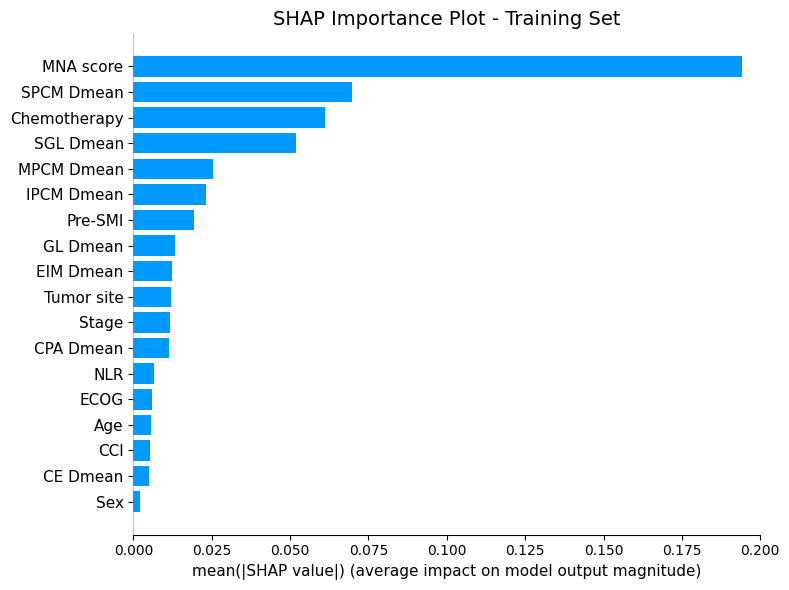

In [5]:
# Training
shap_values_train, rf_shap_train_df = plot_rf_shap_importance(
    explainer=rf_explainer,
    X=X_train_shap,
    feature_names=custom_feature_names,
    title="SHAP Importance Plot - Training Set",
    xlim=(0, 0.20),
    xticks=np.arange(0, 0.201, 0.025),
)

SHAP Importance Plot - Internal Validation Set SHAP shape: (191, 18, 2)


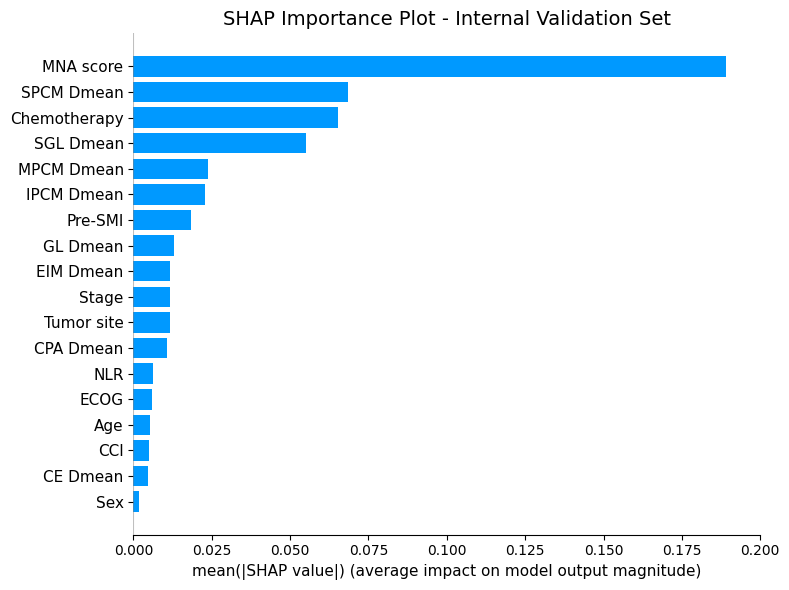

In [6]:
# Internal validation
shap_values_intest, rf_shap_internal_df = plot_rf_shap_importance(
    explainer=rf_explainer,
    X=X_internal_shap,
    feature_names=custom_feature_names,
    title="SHAP Importance Plot - Internal Validation Set",
    xlim=(0, 0.20),
    xticks=np.arange(0, 0.201, 0.025),
)

SHAP Importance Plot - External Validation Set SHAP shape: (388, 18, 2)


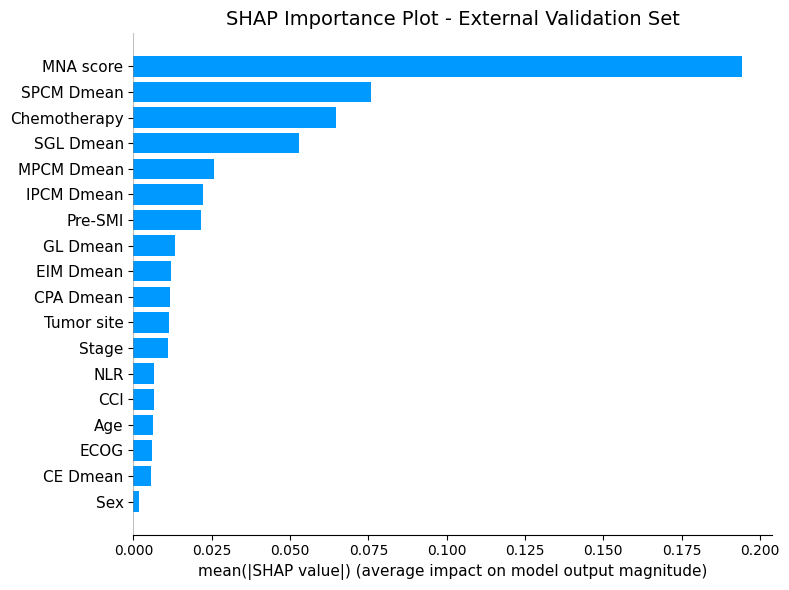

In [7]:
# External validation
shap_values_extest, rf_shap_external_df = plot_rf_shap_importance(
    explainer=rf_explainer,
    X=X_external_shap,
    feature_names=custom_feature_names,
    title="SHAP Importance Plot - External Validation Set",
)

# beeswarm plot

In [8]:
import shap
import numpy as np
import matplotlib.pyplot as plt
# 繪製 Random Forest 的 SHAP Beeswarm 圖
def plot_rf_beeswarm(shap_values, feature_names, title, class_index=1,
                     xlim=None, xticks=None, save_path=None):
    # 取得 SHAP 值與基準值
    values = np.asarray(shap_values.values)
    base_values = np.asarray(shap_values.base_values)
    # 若 SHAP 結果包含不同類別，取得指定類別的 SHAP 值與基準值
    if values.ndim == 3:
        selected_values = values[:, :, class_index]
        selected_base = base_values[:, class_index] if base_values.ndim >= 2 else base_values
    elif values.ndim == 2:
        selected_values = values
        selected_base = base_values
    else:
        raise ValueError(f"Unexpected SHAP value shape: {values.shape}")
     # 檢查 SHAP 特徵數量是否與指定的特徵名稱數量一致
    if selected_values.shape[1] != len(feature_names):
        raise ValueError(
            f"SHAP 有 {selected_values.shape[1]} 個特徵，"
            f"但 feature_names 有 {len(feature_names)} 個"
        )
    # 建立指定類別的 SHAP Explanation
    shap_class1 = shap.Explanation(
        values=selected_values,
        base_values=selected_base,
        data=shap_values.data,
        feature_names=list(feature_names),
    )
    # 顯示 SHAP 圖使用的樣本數及特徵數
    n_samples, n_features = shap_class1.values.shape
    print(f"📊 {title}：樣本數 {n_samples:,}，特徵數 {n_features}")
    # 繪製 Beeswarm 圖
    shap.plots.beeswarm(
        shap_class1,
        max_display=len(feature_names),
        show=False,
    )

    plt.gcf().suptitle(title, fontsize=14)

    if xlim is not None:
        plt.xlim(*xlim)

    if xticks is not None:
        plt.xticks(xticks)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    return shap_class1

📊 SHAP Summary Plot - Training Set：樣本數 445，特徵數 18


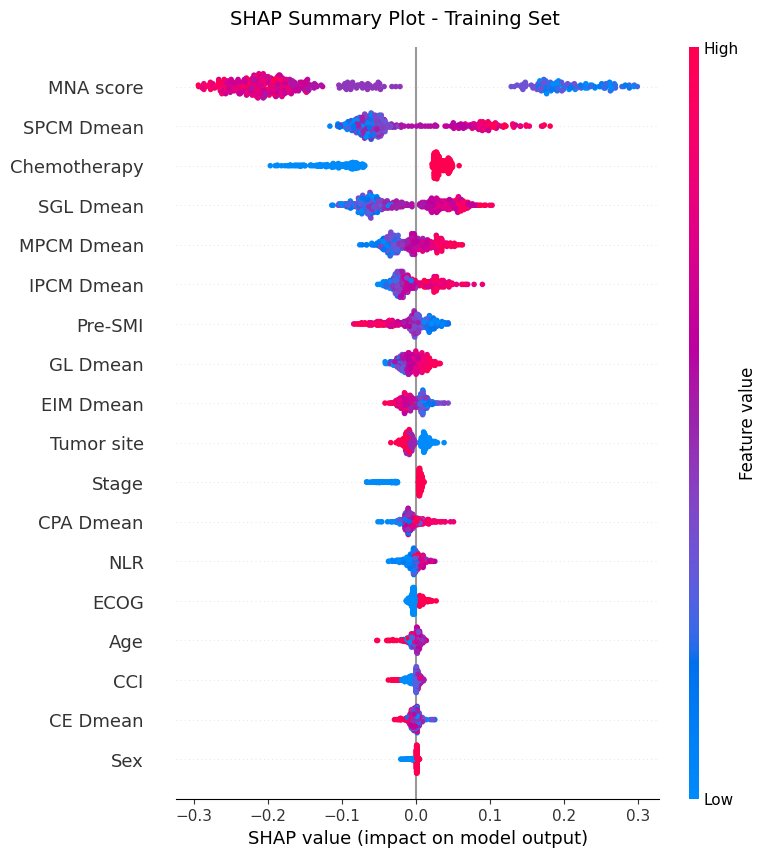

In [9]:
# Training
shap_values_class1 = plot_rf_beeswarm(
    shap_values=shap_values_train,
    feature_names=custom_feature_names,
    title="SHAP Summary Plot - Training Set",
)

📊 SHAP Summary Plot - Internal Validation Set：樣本數 191，特徵數 18


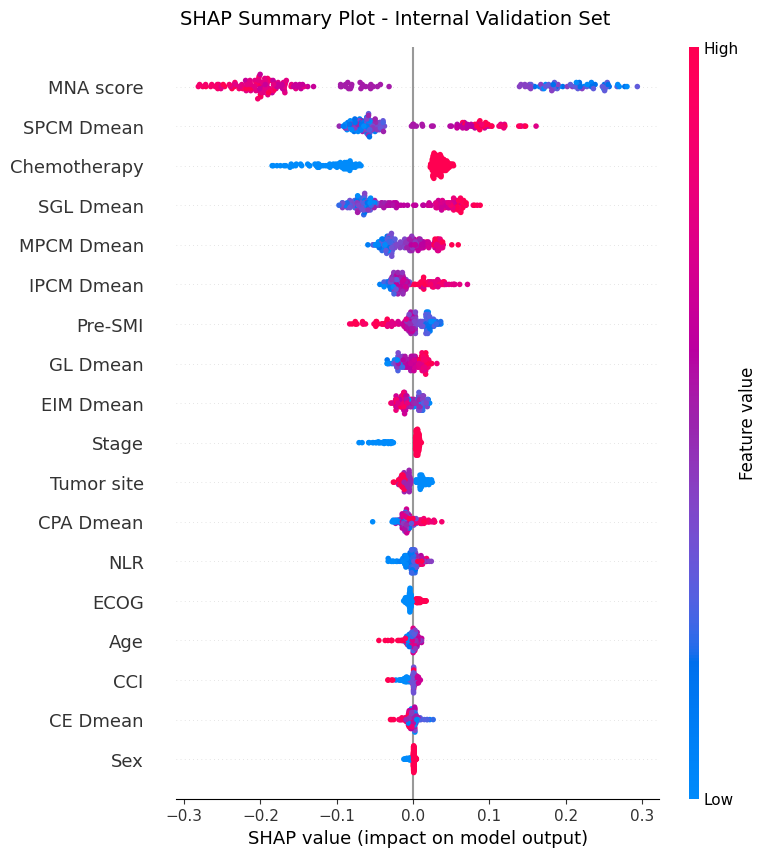

In [10]:
# Internal validation
shap_values_class1_intest = plot_rf_beeswarm(
    shap_values=shap_values_intest,
    feature_names=custom_feature_names,
    title="SHAP Summary Plot - Internal Validation Set",
)

📊 SHAP Summary Plot - External Validation Set：樣本數 388，特徵數 18


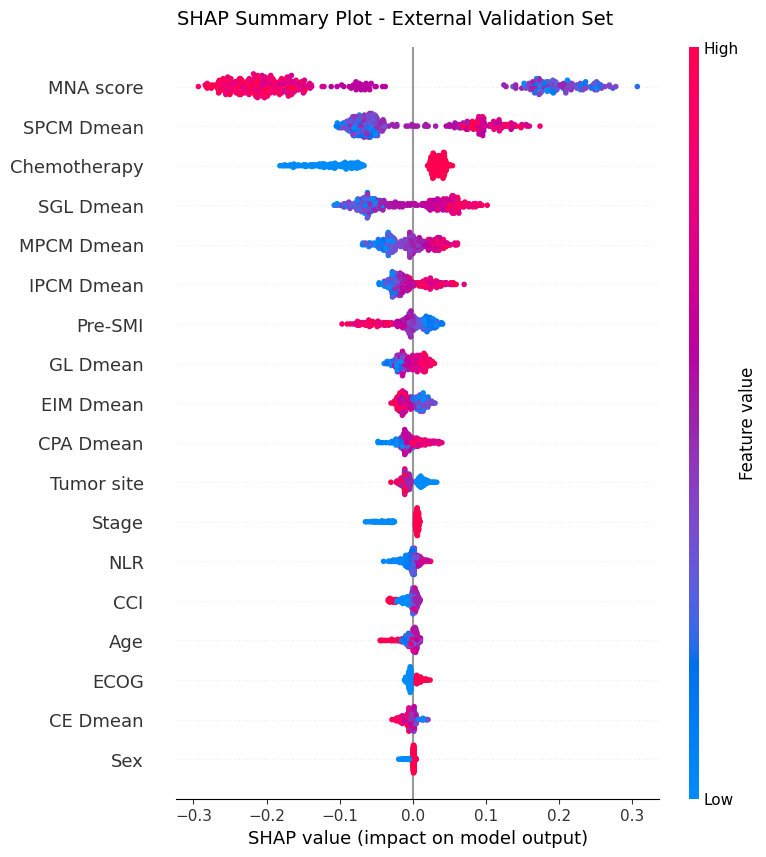

In [11]:
# External validation
shap_values_class1_extval = plot_rf_beeswarm(
    shap_values=shap_values_extest,
    feature_names=custom_feature_names,
    title="SHAP Summary Plot - External Validation Set",
)

# SHAP dependence plot

In [12]:
# 繪圖函式
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
#從 SHAP 結果中取得指定類別的 SHAP 值
def select_shap_class(shap_values, feature_names, class_index=1):
    # 取得 SHAP 值與基準值，轉為 NumPy
    values = np.asarray(shap_values.values)
    base_values = np.asarray(shap_values.base_values)

    if values.ndim == 3:
        selected_values = values[:, :, class_index]
        selected_base = base_values[:, class_index] if base_values.ndim >= 2 else base_values
    elif values.ndim == 2:
        selected_values = values
        selected_base = base_values
    else:
        raise ValueError(f"Unexpected SHAP value shape: {values.shape}")

    return shap.Explanation(
        values=selected_values,
        base_values=selected_base,
        data=np.asarray(shap_values.data),
        feature_names=list(feature_names),
    )
# 繪製 SHAP dependence plot
def plot_rf_shap_dependence(
    shap_values, feature_names, feature_name, title, x_label,
    feature_type="continuous", class_index=1, colorbar_label=None,
    xlim=None, ylim=None, xticks=None, yticks=None, xtick_labels=None,
    category_ticks=None, category_labels=None, figsize=(8, 6),
    point_size=20, save_path=None
):
    # 取得指定類別的 SHAP 結果
    shap_class = select_shap_class(shap_values, feature_names, class_index)
    # 取得指定特徵的位置、原始數值及對應的 SHAP 值
    feature_idx = list(feature_names).index(feature_name)
    feature_values = np.asarray(shap_class.data[:, feature_idx], dtype=float)
    feature_shap = np.asarray(shap_class.values[:, feature_idx], dtype=float)
     # 顯示繪圖資料的樣本數、特徵位置及數值範圍
    print(f"繪圖樣本數：{len(feature_values):,}")
    print(f"{feature_name} 的索引位置：{feature_idx}")
    print(f"{feature_name} 範圍：min = {feature_values.min():.3f}, max = {feature_values.max():.3f}")
    print(f"SHAP 值範圍：min = {feature_shap.min():.3f}, max = {feature_shap.max():.3f}")

    cmap = LinearSegmentedColormap.from_list(
        "RedPurpleBlue", ["#0099FF", "#AA00AA", "#FF0055"]
    )
    # 散點圖
    fig, ax = plt.subplots(figsize=figsize)
    scatter = ax.scatter(
        feature_values, feature_shap, c=feature_values,
        cmap=cmap, s=point_size, edgecolors="none"
    )
    # 顏色條
    cbar = plt.colorbar(scatter, ax=ax, aspect=70, pad=0.02, shrink=1.0)
    cbar.set_label(colorbar_label or x_label, fontsize=10)
    cbar.outline.set_visible(False)
    # 若為類別型特徵，自動設定類別刻度及標籤
    if feature_type == "categorical":
        if category_ticks is None:
            category_ticks = sorted(np.unique(feature_values))

        if category_labels is None:
            category_labels = [str(value) for value in category_ticks]

        cbar.set_ticks(category_ticks)
        cbar.set_ticklabels(category_labels)

        if xticks is None:
            xticks = category_ticks
        if xtick_labels is None:
            xtick_labels = category_labels

    ax.set_title(title, fontsize=14)
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel("SHAP value", fontsize=12)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.grid(False)

    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if xticks is not None:
        ax.set_xticks(xticks)
    if yticks is not None:
        ax.set_yticks(yticks)
    if xtick_labels is not None:
        ax.set_xticklabels(xtick_labels, fontsize=12)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return pd.DataFrame({
        "Feature value": feature_values,
        "SHAP value": feature_shap,
    })

繪圖樣本數：445
CE Dmean 的索引位置：5
CE Dmean 範圍：min = 8.304, max = 51.122
SHAP 值範圍：min = -0.029, max = 0.025


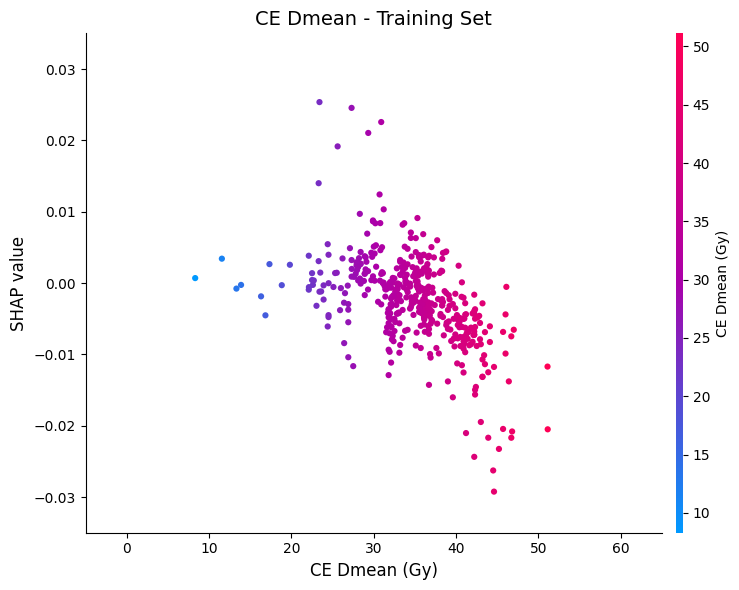

In [13]:
# CE Dmean - Training
ce_train_df = plot_rf_shap_dependence(
    shap_values=shap_values_train,
    feature_names=custom_feature_names,
    feature_name="CE Dmean",
    title="CE Dmean - Training Set",
    x_label="CE Dmean (Gy)",
    feature_type="continuous",
    xlim=(-5, 65),
    ylim=(-0.035, 0.035),
)

繪圖樣本數：191
CE Dmean 的索引位置：5
CE Dmean 範圍：min = 8.404, max = 49.000
SHAP 值範圍：min = -0.030, max = 0.026


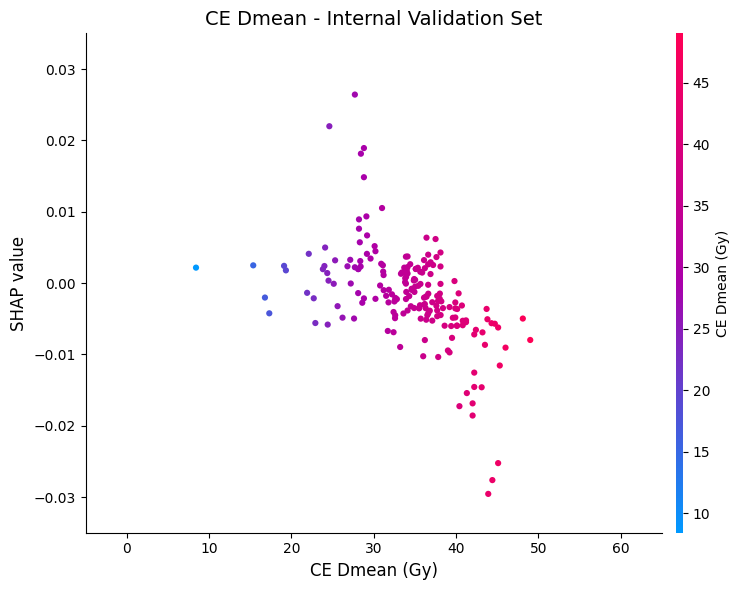

In [14]:
# CE Dmean - Internal validation
ce_internal_df = plot_rf_shap_dependence(
    shap_values=shap_values_intest,
    feature_names=custom_feature_names,
    feature_name="CE Dmean",
    title="CE Dmean - Internal Validation Set",
    x_label="CE Dmean (Gy)",
    feature_type="continuous",
    xlim=(-5, 65),
    ylim=(-0.035, 0.035),
)

繪圖樣本數：388
CE Dmean 的索引位置：5
CE Dmean 範圍：min = 0.800, max = 61.200
SHAP 值範圍：min = -0.029, max = 0.021


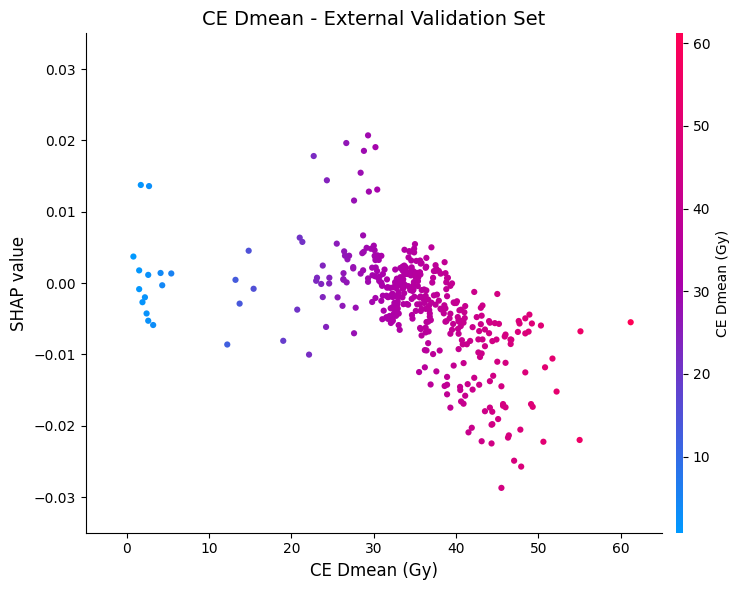

In [15]:
# CE Dmean - External validation
ce_external_df = plot_rf_shap_dependence(
    shap_values=shap_values_extest,
    feature_names=custom_feature_names,
    feature_name="CE Dmean",
    title="CE Dmean - External Validation Set",
    x_label="CE Dmean (Gy)",
    feature_type="continuous",
    xlim=(-5, 65),
    ylim=(-0.035, 0.035),
)

繪圖樣本數：445
CPA Dmean 的索引位置：6
CPA Dmean 範圍：min = 23.722, max = 53.500
SHAP 值範圍：min = -0.052, max = 0.051


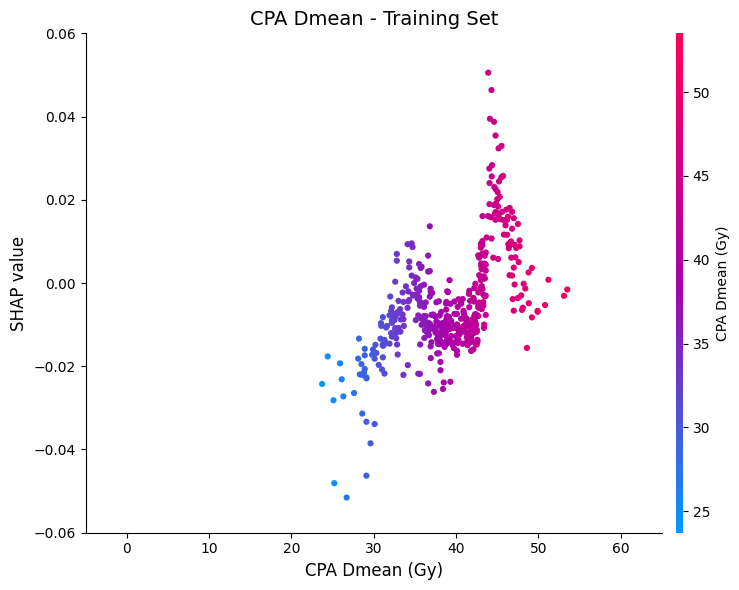

In [21]:
# CPA Dmean - Training

cpa_train_df = plot_rf_shap_dependence(
    shap_values=shap_values_train,
    feature_names=custom_feature_names,
    feature_name="CPA Dmean",
    title="CPA Dmean - Training Set",
    x_label="CPA Dmean (Gy)",
    colorbar_label="CPA Dmean (Gy)",
    feature_type="continuous",
    xlim=(-5, 65),
    ylim=(-0.06, 0.06),
    xticks=range(0, 66, 10),
    yticks=np.arange(-0.06, 0.061, 0.02),
)

繪圖樣本數：191
CPA Dmean 的索引位置：6
CPA Dmean 範圍：min = 25.400, max = 53.100
SHAP 值範圍：min = -0.053, max = 0.038


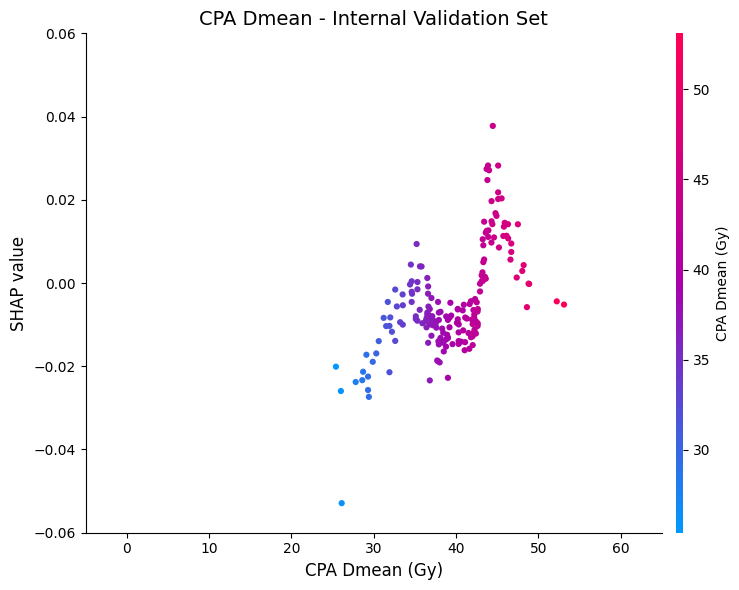

In [22]:
# CPA Dmean - Internal validation

cpa_internal_df = plot_rf_shap_dependence(
    shap_values=shap_values_intest,
    feature_names=custom_feature_names,
    feature_name="CPA Dmean",
    title="CPA Dmean - Internal Validation Set",
    x_label="CPA Dmean (Gy)",
    colorbar_label="CPA Dmean (Gy)",
    feature_type="continuous",
    xlim=(-5, 65),
    ylim=(-0.06, 0.06),
    xticks=range(0, 66, 10),
    yticks=np.arange(-0.06, 0.061, 0.02),
)

繪圖樣本數：388
CPA Dmean 的索引位置：6
CPA Dmean 範圍：min = 1.400, max = 58.800
SHAP 值範圍：min = -0.048, max = 0.040


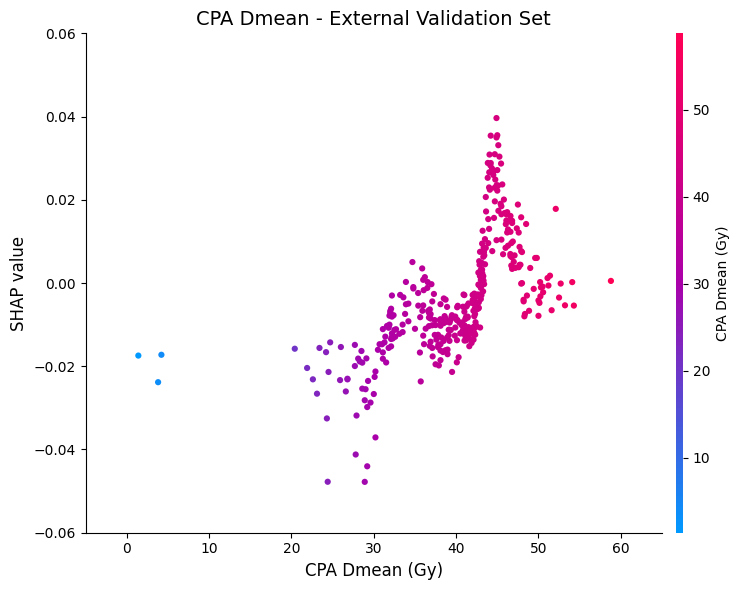

In [23]:
# CPA Dmean - External validation

cpa_external_df = plot_rf_shap_dependence(
    shap_values=shap_values_extest,
    feature_names=custom_feature_names,
    feature_name="CPA Dmean",
    title="CPA Dmean - External Validation Set",
    x_label="CPA Dmean (Gy)",
    colorbar_label="CPA Dmean (Gy)",
    feature_type="continuous",
    xlim=(-5, 65),
    ylim=(-0.06, 0.06),
    xticks=range(0, 66, 10),
    yticks=np.arange(-0.06, 0.061, 0.02),
)

繪圖樣本數：445
EIM Dmean 的索引位置：7
EIM Dmean 範圍：min = 13.300, max = 55.100
SHAP 值範圍：min = -0.042, max = 0.043


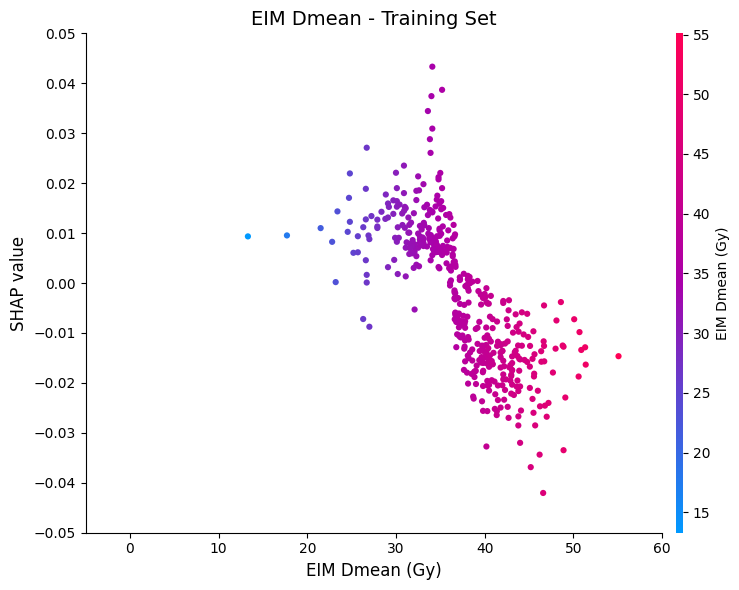

In [24]:
# EIM Dmean - Training

eim_train_df = plot_rf_shap_dependence(
    shap_values=shap_values_train,
    feature_names=custom_feature_names,
    feature_name="EIM Dmean",
    title="EIM Dmean - Training Set",
    x_label="EIM Dmean (Gy)",
    colorbar_label="EIM Dmean (Gy)",
    feature_type="continuous",
    xlim=(-5, 60),
    ylim=(-0.05, 0.05),
    xticks=range(0, 61, 10),
    yticks=np.arange(-0.05, 0.051, 0.01),
)

繪圖樣本數：191
EIM Dmean 的索引位置：7
EIM Dmean 範圍：min = 16.633, max = 53.718
SHAP 值範圍：min = -0.029, max = 0.022


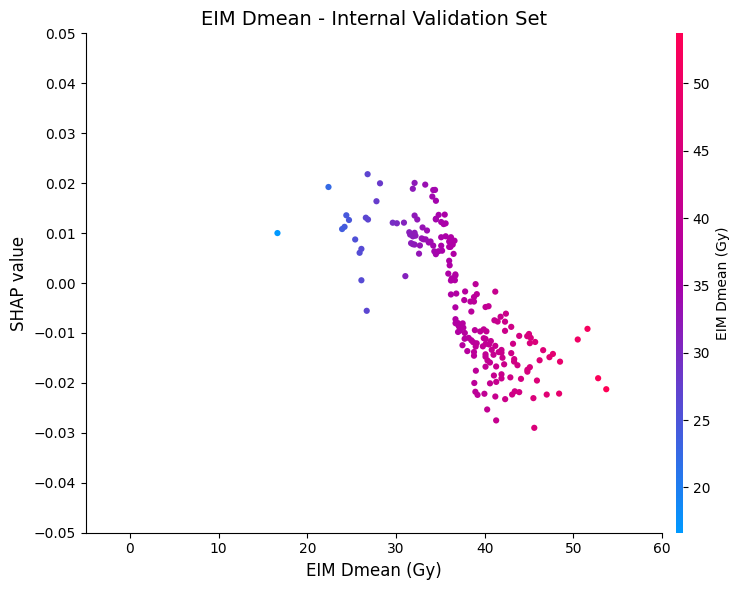

In [25]:
# EIM Dmean - Internal validation

eim_internal_df = plot_rf_shap_dependence(
    shap_values=shap_values_intest,
    feature_names=custom_feature_names,
    feature_name="EIM Dmean",
    title="EIM Dmean - Internal Validation Set",
    x_label="EIM Dmean (Gy)",
    colorbar_label="EIM Dmean (Gy)",
    feature_type="continuous",
    xlim=(-5, 60),
    ylim=(-0.05, 0.05),
    xticks=range(0, 61, 10),
    yticks=np.arange(-0.05, 0.051, 0.01),
)

繪圖樣本數：388
EIM Dmean 的索引位置：7
EIM Dmean 範圍：min = 1.000, max = 56.200
SHAP 值範圍：min = -0.030, max = 0.030


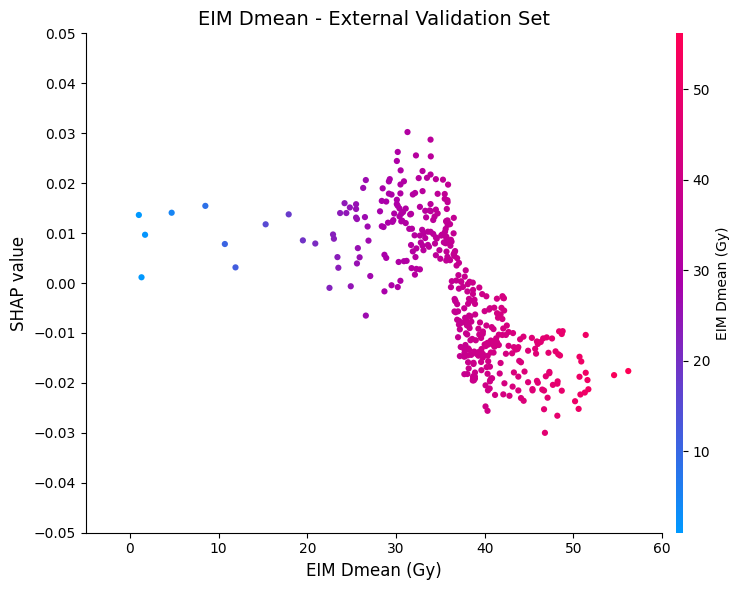

In [26]:
# EIM Dmean - External validation

eim_external_df = plot_rf_shap_dependence(
    shap_values=shap_values_extest,
    feature_names=custom_feature_names,
    feature_name="EIM Dmean",
    title="EIM Dmean - External Validation Set",
    x_label="EIM Dmean (Gy)",
    colorbar_label="EIM Dmean (Gy)",
    feature_type="continuous",
    xlim=(-5, 60),
    ylim=(-0.05, 0.05),
    xticks=range(0, 61, 10),
    yticks=np.arange(-0.05, 0.051, 0.01),
)

繪圖樣本數：445
GL Dmean 的索引位置：8
GL Dmean 範圍：min = 24.300, max = 53.400
SHAP 值範圍：min = -0.042, max = 0.033


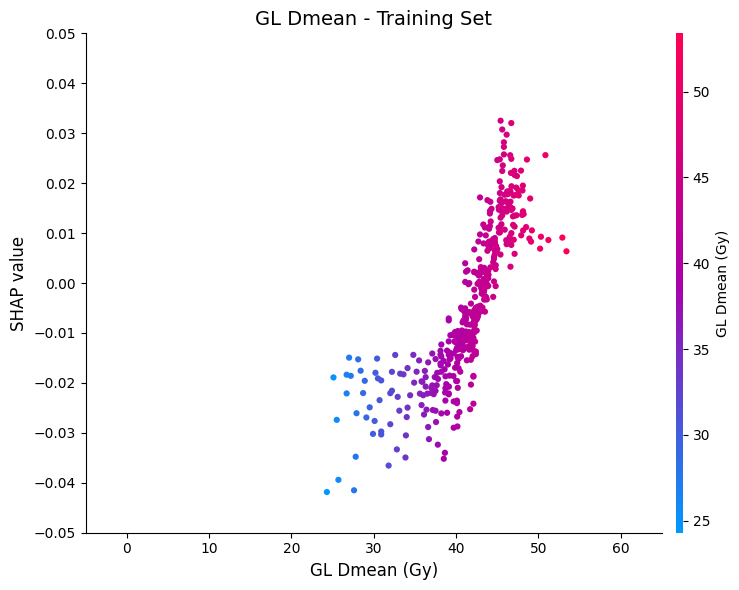

In [28]:
# GL Dmean - Training
gl_train_df = plot_rf_shap_dependence(
    shap_values=shap_values_train,
    feature_names=custom_feature_names,
    feature_name="GL Dmean",
    title="GL Dmean - Training Set",
    x_label="GL Dmean (Gy)",
    colorbar_label="GL Dmean (Gy)",
    feature_type="continuous",
    xlim=(-5, 65),
    ylim=(-0.05, 0.05),
    xticks=range(0, 66, 10),
    yticks=np.arange(-0.05, 0.051, 0.01),
)


繪圖樣本數：191
GL Dmean 的索引位置：8
GL Dmean 範圍：min = 28.100, max = 55.300
SHAP 值範圍：min = -0.034, max = 0.031


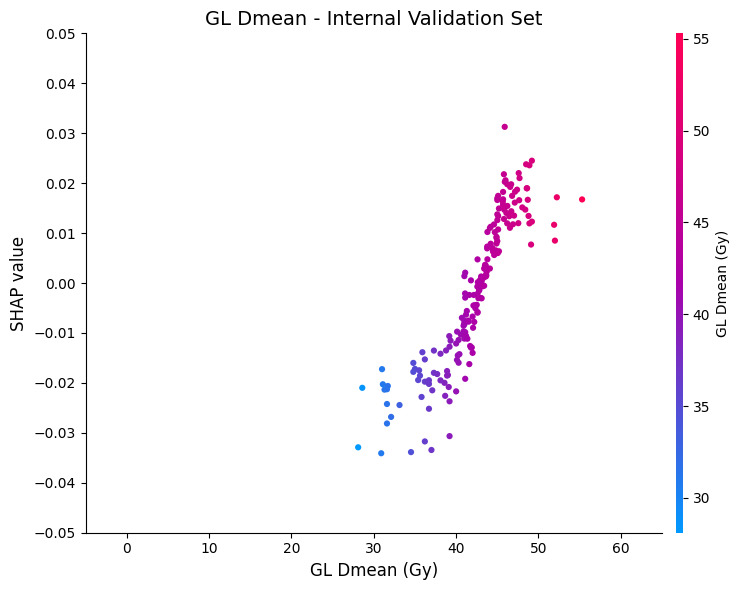

In [29]:
# GL Dmean - Internal validation
gl_internal_df = plot_rf_shap_dependence(
    shap_values=shap_values_intest,
    feature_names=custom_feature_names,
    feature_name="GL Dmean",
    title="GL Dmean - Internal Validation Set",
    x_label="GL Dmean (Gy)",
    colorbar_label="GL Dmean (Gy)",
    feature_type="continuous",
    xlim=(-5, 65),
    ylim=(-0.05, 0.05),
    xticks=range(0, 66, 10),
    yticks=np.arange(-0.05, 0.051, 0.01),
)


繪圖樣本數：388
GL Dmean 的索引位置：8
GL Dmean 範圍：min = 1.500, max = 60.900
SHAP 值範圍：min = -0.039, max = 0.029


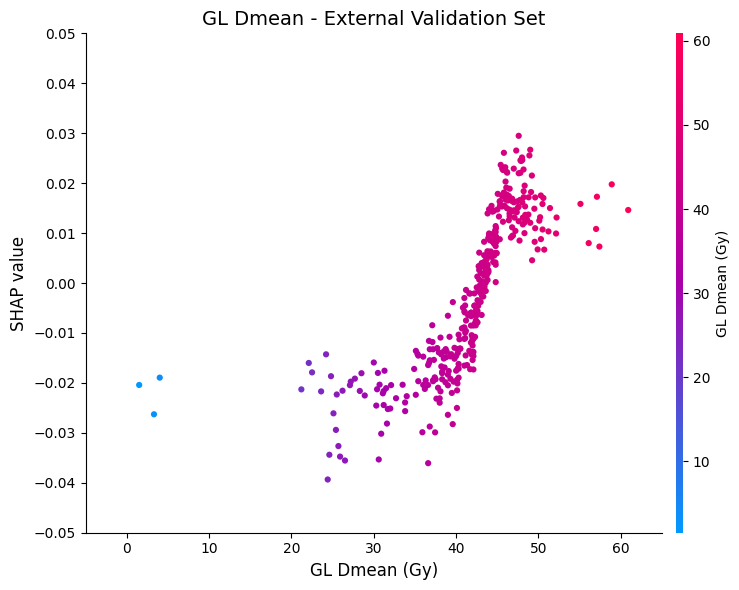

In [27]:
# GL Dmean - External validation
gl_external_df = plot_rf_shap_dependence(
    shap_values=shap_values_extest,
    feature_names=custom_feature_names,
    feature_name="GL Dmean",
    title="GL Dmean - External Validation Set",
    x_label="GL Dmean (Gy)",
    colorbar_label="GL Dmean (Gy)",
    feature_type="continuous",
    xlim=(-5, 65),
    ylim=(-0.05, 0.05),
    xticks=range(0, 66, 10),
    yticks=np.arange(-0.05, 0.051, 0.01),
)

繪圖樣本數：445
IPCM Dmean 的索引位置：9
IPCM Dmean 範圍：min = 28.600, max = 57.100
SHAP 值範圍：min = -0.052, max = 0.089


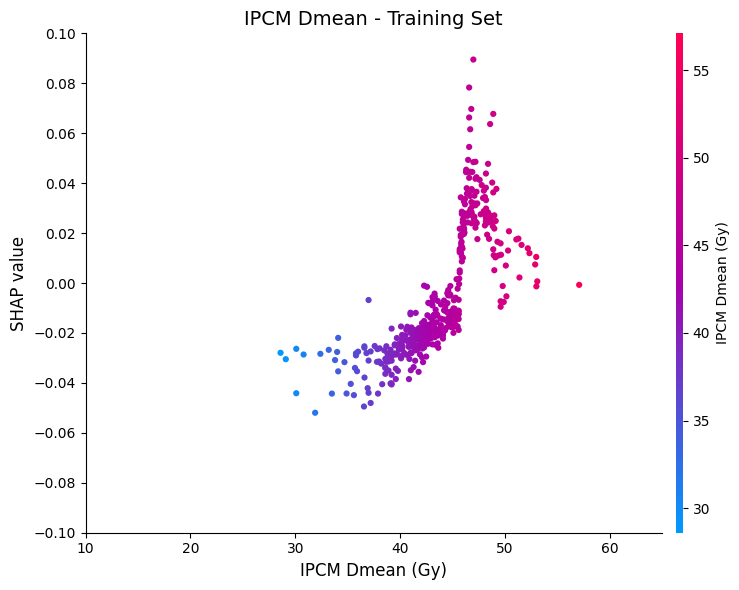

In [30]:
# IPCM Dmean - Training

ipcm_train_df = plot_rf_shap_dependence(
    shap_values=shap_values_train,
    feature_names=custom_feature_names,
    feature_name="IPCM Dmean",
    title="IPCM Dmean - Training Set",
    x_label="IPCM Dmean (Gy)",
    colorbar_label="IPCM Dmean (Gy)",
    feature_type="continuous",
    xlim=(10, 65),
    ylim=(-0.10, 0.10),
    xticks=range(10, 66, 10),
    yticks=np.arange(-0.10, 0.101, 0.02),
)


繪圖樣本數：191
IPCM Dmean 的索引位置：9
IPCM Dmean 範圍：min = 29.200, max = 57.600
SHAP 值範圍：min = -0.043, max = 0.071


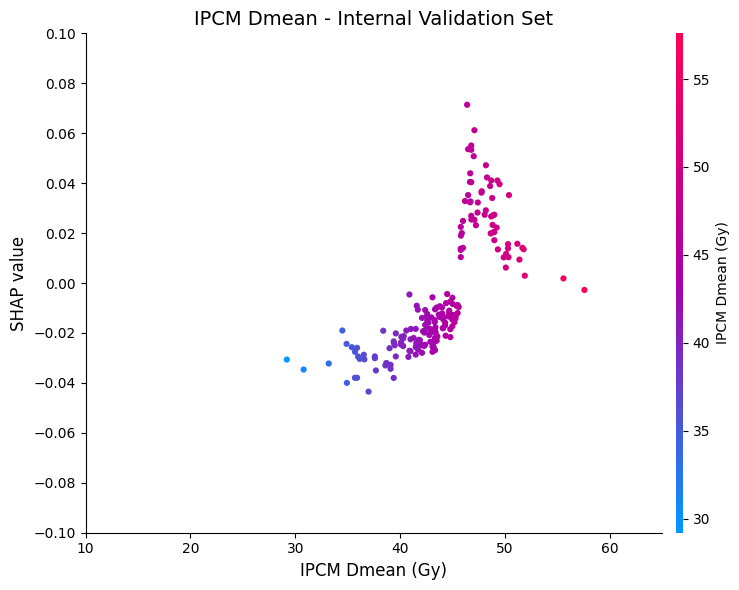

In [31]:
# IPCM Dmean - Internal validation

ipcm_internal_df = plot_rf_shap_dependence(
    shap_values=shap_values_intest,
    feature_names=custom_feature_names,
    feature_name="IPCM Dmean",
    title="IPCM Dmean - Internal Validation Set",
    x_label="IPCM Dmean (Gy)",
    colorbar_label="IPCM Dmean (Gy)",
    feature_type="continuous",
    xlim=(10, 65),
    ylim=(-0.10, 0.10),
    xticks=range(10, 66, 10),
    yticks=np.arange(-0.10, 0.101, 0.02),
)

繪圖樣本數：388
IPCM Dmean 的索引位置：9
IPCM Dmean 範圍：min = 16.200, max = 58.900
SHAP 值範圍：min = -0.046, max = 0.070


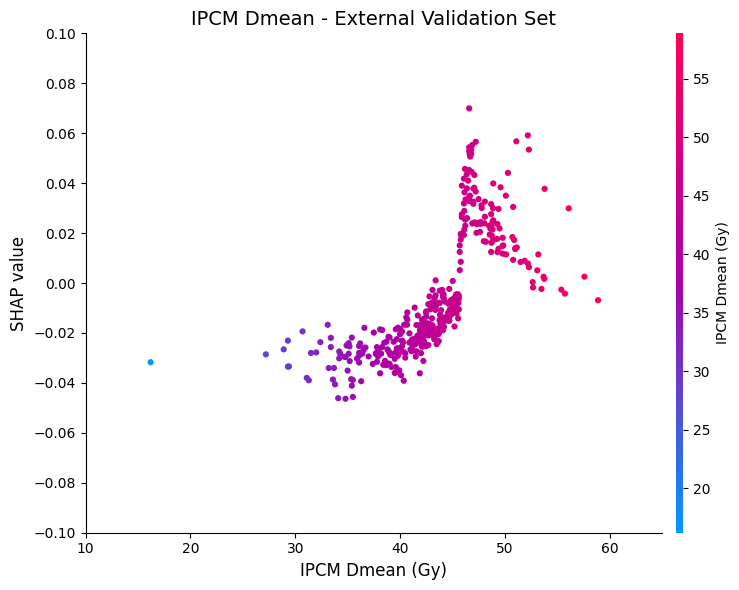

In [32]:
# IPCM Dmean - External validation

ipcm_external_df = plot_rf_shap_dependence(
    shap_values=shap_values_extest,
    feature_names=custom_feature_names,
    feature_name="IPCM Dmean",
    title="IPCM Dmean - External Validation Set",
    x_label="IPCM Dmean (Gy)",
    colorbar_label="IPCM Dmean (Gy)",
    feature_type="continuous",
    xlim=(10, 65),
    ylim=(-0.10, 0.10),
    xticks=range(10, 66, 10),
    yticks=np.arange(-0.10, 0.101, 0.02),
)

繪圖樣本數：445
MPCM Dmean 的索引位置：10
MPCM Dmean 範圍：min = 32.900, max = 62.300
SHAP 值範圍：min = -0.076, max = 0.063


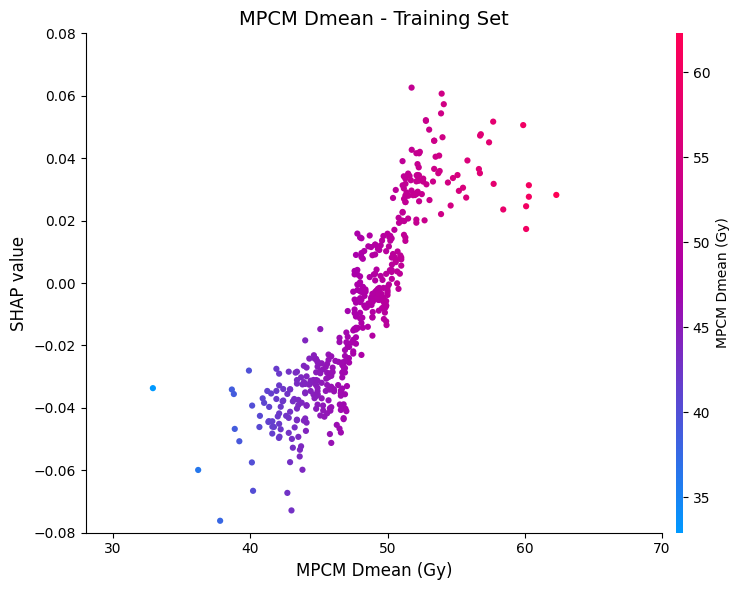

In [33]:
# MPCM Dmean - Training
mpcm_train_df = plot_rf_shap_dependence(
    shap_values=shap_values_train,
    feature_names=custom_feature_names,
    feature_name="MPCM Dmean",
    title="MPCM Dmean - Training Set",
    x_label="MPCM Dmean (Gy)",
    colorbar_label="MPCM Dmean (Gy)",
    feature_type="continuous",
    xlim=(28, 70),
    ylim=(-0.08, 0.08),
    xticks=range(30, 71, 10),
    yticks=np.arange(-0.08, 0.081, 0.02),
)

繪圖樣本數：191
MPCM Dmean 的索引位置：10
MPCM Dmean 範圍：min = 38.505, max = 63.034
SHAP 值範圍：min = -0.059, max = 0.059


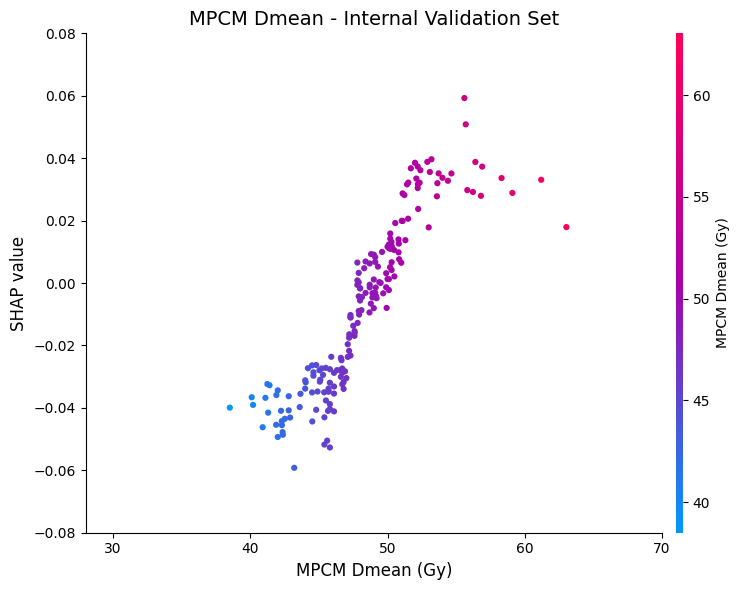

In [34]:
# MPCM Dmean - Internal validation
mpcm_internal_df = plot_rf_shap_dependence(
    shap_values=shap_values_intest,
    feature_names=custom_feature_names,
    feature_name="MPCM Dmean",
    title="MPCM Dmean - Internal Validation Set",
    x_label="MPCM Dmean (Gy)",
    colorbar_label="MPCM Dmean (Gy)",
    feature_type="continuous",
    xlim=(28, 70),
    ylim=(-0.08, 0.08),
    xticks=range(30, 71, 10),
    yticks=np.arange(-0.08, 0.081, 0.02),
)


繪圖樣本數：388
MPCM Dmean 的索引位置：10
MPCM Dmean 範圍：min = 33.100, max = 64.900
SHAP 值範圍：min = -0.069, max = 0.061


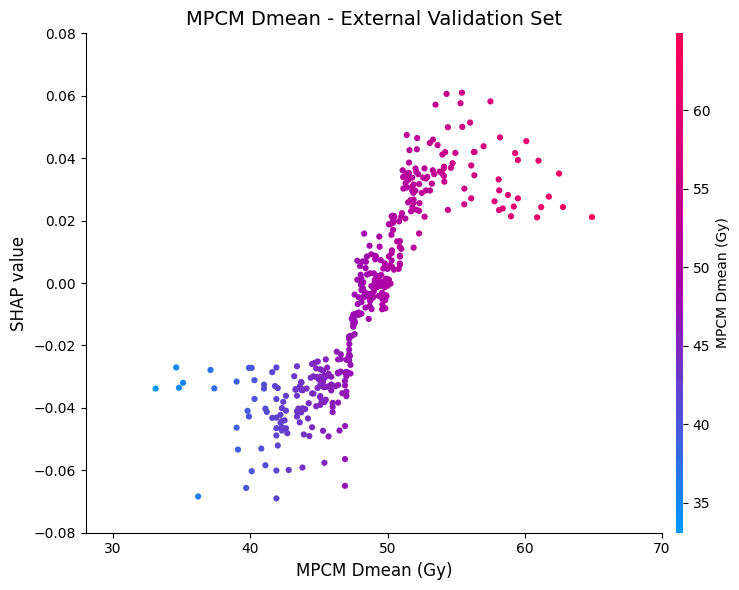

In [35]:
# MPCM Dmean - External validation
mpcm_external_df = plot_rf_shap_dependence(
    shap_values=shap_values_extest,
    feature_names=custom_feature_names,
    feature_name="MPCM Dmean",
    title="MPCM Dmean - External Validation Set",
    x_label="MPCM Dmean (Gy)",
    colorbar_label="MPCM Dmean (Gy)",
    feature_type="continuous",
    xlim=(28, 70),
    ylim=(-0.08, 0.08),
    xticks=range(30, 71, 10),
    yticks=np.arange(-0.08, 0.081, 0.02),
)

繪圖樣本數：445
SPCM Dmean 的索引位置：11
SPCM Dmean 範圍：min = 32.800, max = 66.100
SHAP 值範圍：min = -0.116, max = 0.181


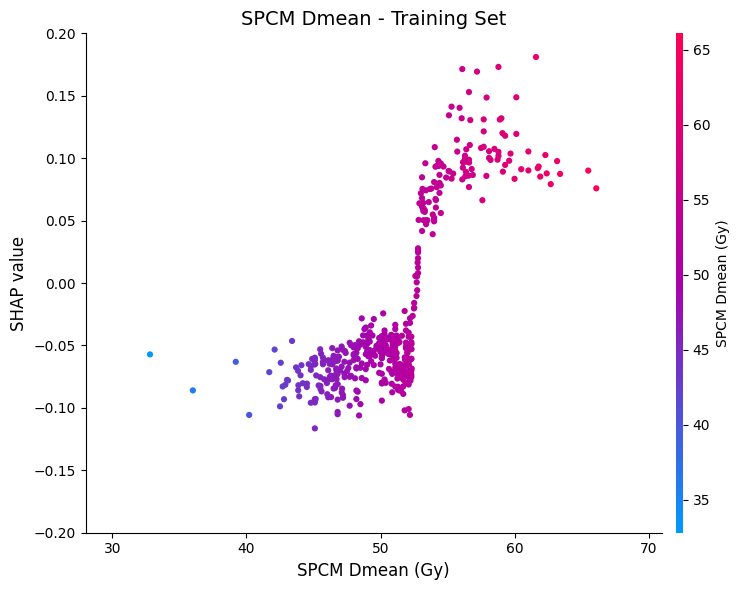

繪圖樣本數：191
SPCM Dmean 的索引位置：11
SPCM Dmean 範圍：min = 42.036, max = 63.500
SHAP 值範圍：min = -0.097, max = 0.161


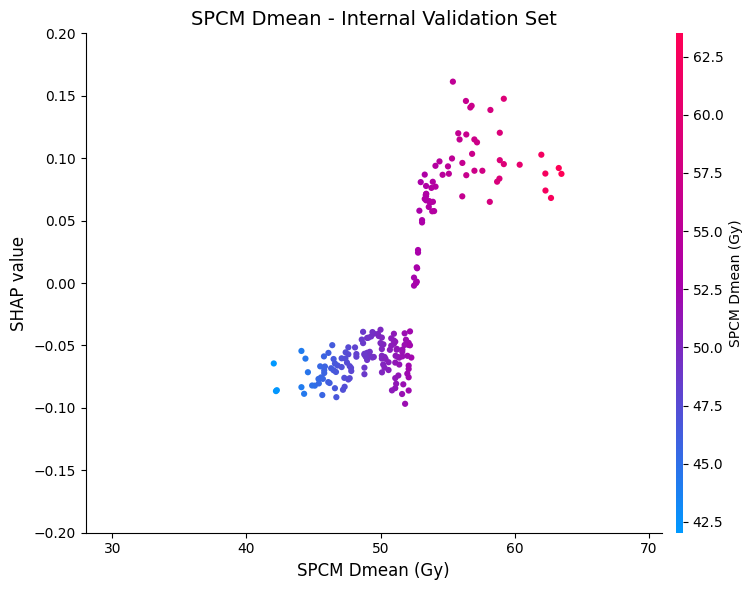

繪圖樣本數：388
SPCM Dmean 的索引位置：11
SPCM Dmean 範圍：min = 34.600, max = 65.906
SHAP 值範圍：min = -0.105, max = 0.174


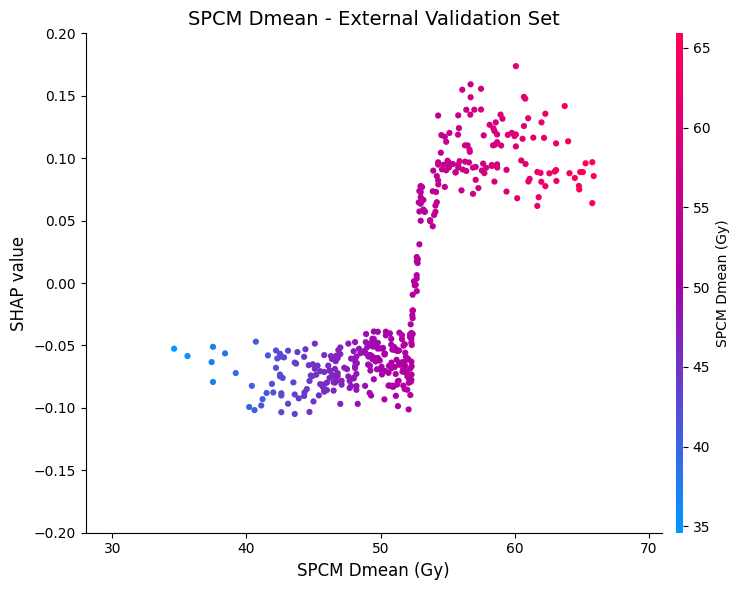

In [36]:
# SPCM 
spcm_train_df = plot_rf_shap_dependence(
    shap_values_train, custom_feature_names, "SPCM Dmean",
    "SPCM Dmean - Training Set", "SPCM Dmean (Gy)",
    feature_type="continuous", colorbar_label="SPCM Dmean (Gy)",
    xlim=(28, 71), ylim=(-0.20, 0.20),
    xticks=range(30, 73, 10), yticks=np.arange(-0.20, 0.201, 0.05),
)

spcm_internal_df = plot_rf_shap_dependence(
    shap_values_intest, custom_feature_names, "SPCM Dmean",
    "SPCM Dmean - Internal Validation Set", "SPCM Dmean (Gy)",
    feature_type="continuous", colorbar_label="SPCM Dmean (Gy)",
    xlim=(28, 71), ylim=(-0.20, 0.20),
    xticks=range(30, 73, 10), yticks=np.arange(-0.20, 0.201, 0.05),
)

spcm_external_df = plot_rf_shap_dependence(
    shap_values_extest, custom_feature_names, "SPCM Dmean",
    "SPCM Dmean - External Validation Set", "SPCM Dmean (Gy)",
    feature_type="continuous", colorbar_label="SPCM Dmean (Gy)",
    xlim=(28, 71), ylim=(-0.20, 0.20),
    xticks=range(30, 73, 10), yticks=np.arange(-0.20, 0.201, 0.05),
)

繪圖樣本數：445
SGL Dmean 的索引位置：12
SGL Dmean 範圍：min = 29.100, max = 63.700
SHAP 值範圍：min = -0.114, max = 0.103


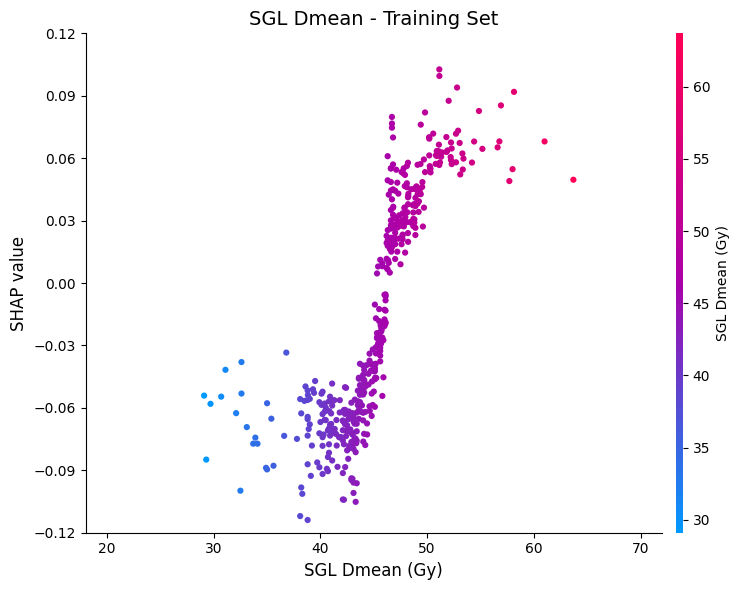

繪圖樣本數：191
SGL Dmean 的索引位置：12
SGL Dmean 範圍：min = 29.500, max = 68.000
SHAP 值範圍：min = -0.097, max = 0.088


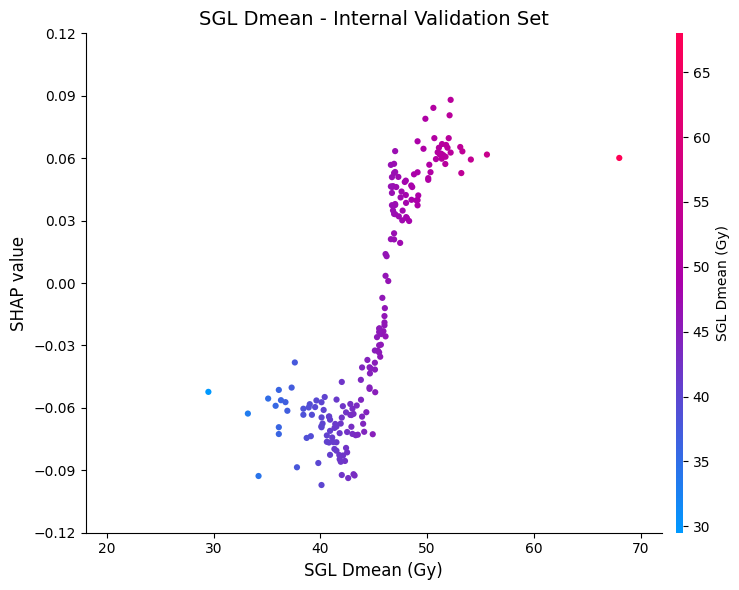

繪圖樣本數：388
SGL Dmean 的索引位置：12
SGL Dmean 範圍：min = 24.000, max = 64.100
SHAP 值範圍：min = -0.108, max = 0.102


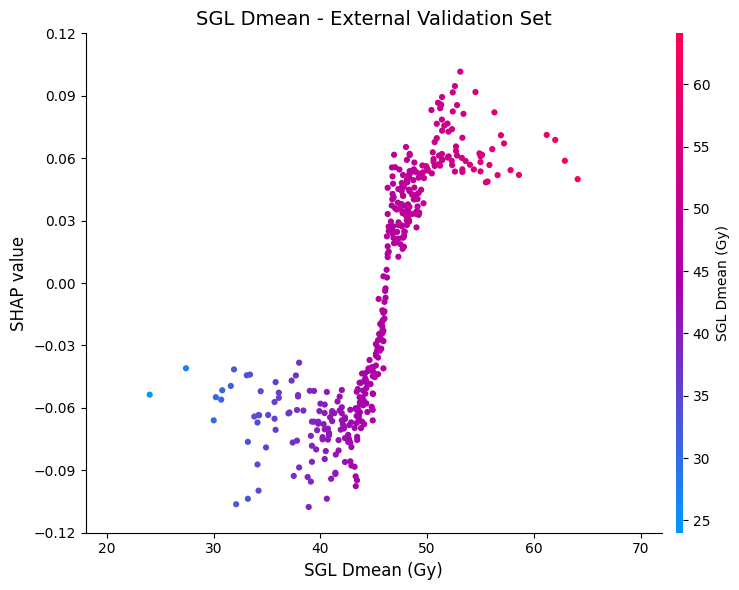

In [37]:
# SGL
sgl_train_df = plot_rf_shap_dependence(
    shap_values_train, custom_feature_names, "SGL Dmean",
    "SGL Dmean - Training Set", "SGL Dmean (Gy)",
    feature_type="continuous", colorbar_label="SGL Dmean (Gy)",
    xlim=(18, 72), ylim=(-0.12, 0.12),
    xticks=range(20, 73, 10), yticks=np.arange(-0.12, 0.121, 0.03),
)

sgl_internal_df = plot_rf_shap_dependence(
    shap_values_intest, custom_feature_names, "SGL Dmean",
    "SGL Dmean - Internal Validation Set", "SGL Dmean (Gy)",
    feature_type="continuous", colorbar_label="SGL Dmean (Gy)",
    xlim=(18, 72), ylim=(-0.12, 0.12),
    xticks=range(20, 73, 10), yticks=np.arange(-0.12, 0.121, 0.03),
)

sgl_external_df = plot_rf_shap_dependence(
    shap_values_extest, custom_feature_names, "SGL Dmean",
    "SGL Dmean - External Validation Set", "SGL Dmean (Gy)",
    feature_type="continuous", colorbar_label="SGL Dmean (Gy)",
    xlim=(18, 72), ylim=(-0.12, 0.12),
    xticks=range(20, 73, 10), yticks=np.arange(-0.12, 0.121, 0.03),
)

繪圖樣本數：445
Pre-SMI 的索引位置：2
Pre-SMI 範圍：min = 26.008, max = 85.297
SHAP 值範圍：min = -0.084, max = 0.044


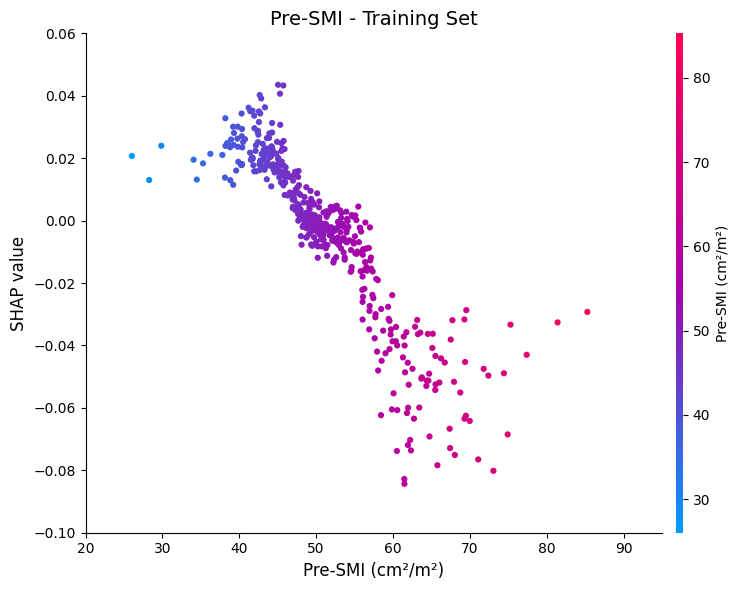

繪圖樣本數：191
Pre-SMI 的索引位置：2
Pre-SMI 範圍：min = 29.183, max = 76.708
SHAP 值範圍：min = -0.083, max = 0.037


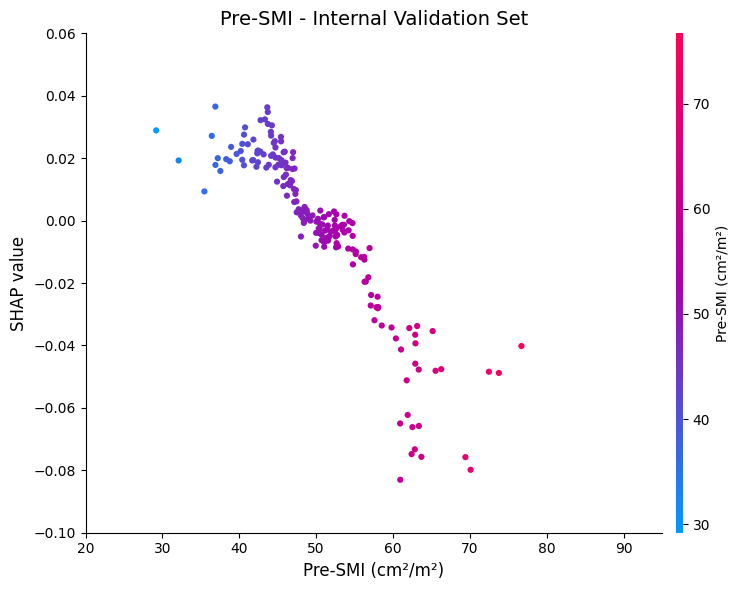

繪圖樣本數：388
Pre-SMI 的索引位置：2
Pre-SMI 範圍：min = 34.637, max = 80.477
SHAP 值範圍：min = -0.097, max = 0.041


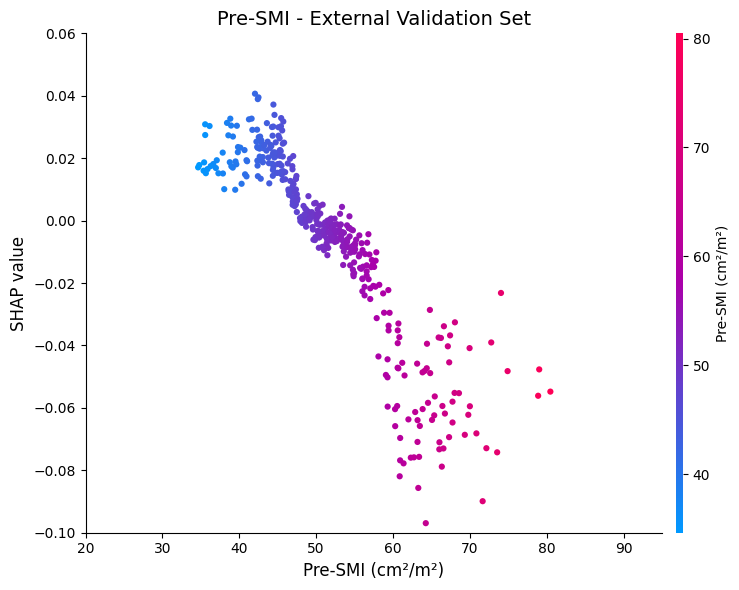

In [38]:
#  Pre-SMI
presmi_train_df = plot_rf_shap_dependence(
    shap_values_train, custom_feature_names, "Pre-SMI",
    "Pre-SMI - Training Set", "Pre-SMI (cm²/m²)",
    feature_type="continuous", colorbar_label="Pre-SMI (cm²/m²)",
    xlim=(20, 95), ylim=(-0.10, 0.06),
    xticks=range(20, 96, 10), yticks=np.arange(-0.10, 0.061, 0.02),
)

presmi_internal_df = plot_rf_shap_dependence(
    shap_values_intest, custom_feature_names, "Pre-SMI",
    "Pre-SMI - Internal Validation Set", "Pre-SMI (cm²/m²)",
    feature_type="continuous", colorbar_label="Pre-SMI (cm²/m²)",
    xlim=(20, 95), ylim=(-0.10, 0.06),
    xticks=range(20, 96, 10), yticks=np.arange(-0.10, 0.061, 0.02),
)

presmi_external_df = plot_rf_shap_dependence(
    shap_values_extest, custom_feature_names, "Pre-SMI",
    "Pre-SMI - External Validation Set", "Pre-SMI (cm²/m²)",
    feature_type="continuous", colorbar_label="Pre-SMI (cm²/m²)",
    xlim=(20, 95), ylim=(-0.10, 0.06),
    xticks=range(20, 96, 10), yticks=np.arange(-0.10, 0.061, 0.02),
)

繪圖樣本數：445
CCI 的索引位置：3
CCI 範圍：min = 0.000, max = 6.000
SHAP 值範圍：min = -0.038, max = 0.010


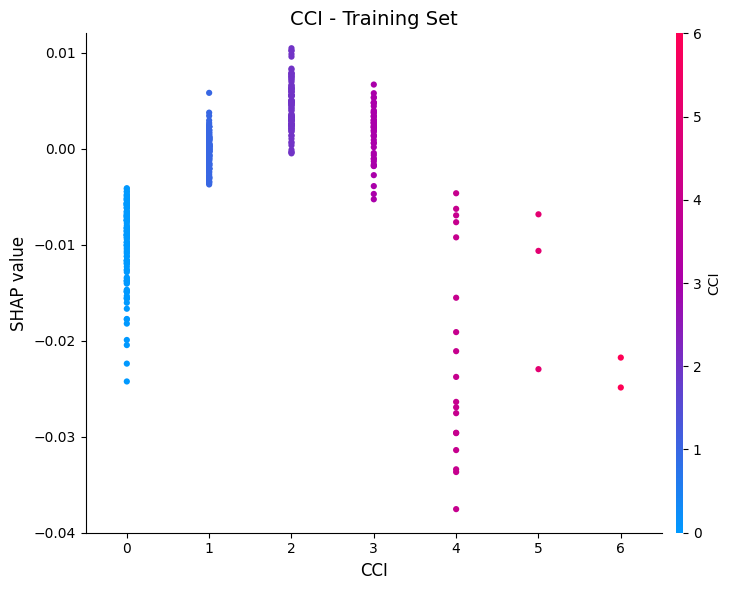

繪圖樣本數：191
CCI 的索引位置：3
CCI 範圍：min = 0.000, max = 6.000
SHAP 值範圍：min = -0.033, max = 0.010


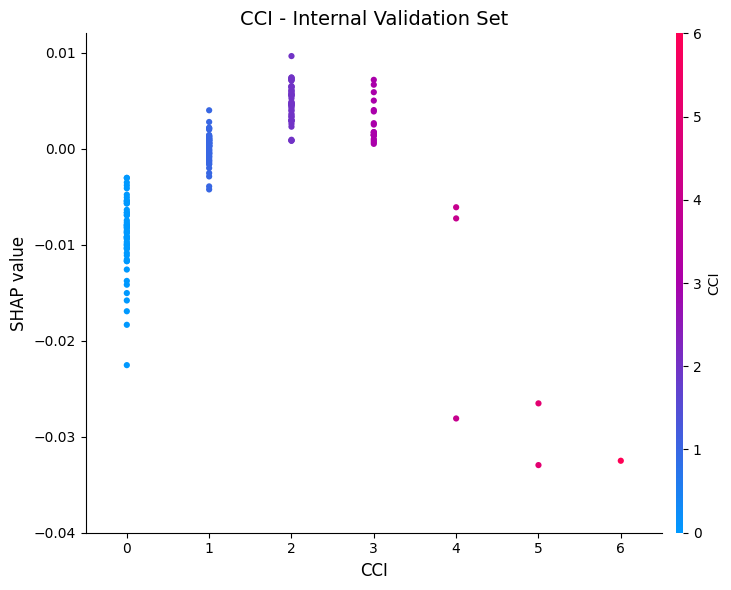

繪圖樣本數：388
CCI 的索引位置：3
CCI 範圍：min = 0.000, max = 6.000
SHAP 值範圍：min = -0.034, max = 0.010


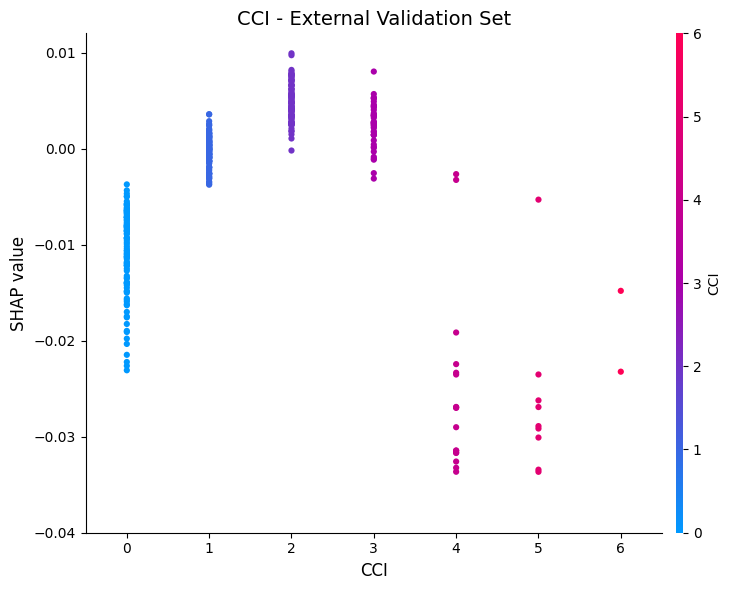

In [39]:
#  CCI
cci_train_df = plot_rf_shap_dependence(
    shap_values_train, custom_feature_names, "CCI",
    "CCI - Training Set", "CCI",
    feature_type="continuous", colorbar_label="CCI",
    xlim=(-0.5, 6.5), ylim=(-0.04, 0.012),
    xticks=range(0, 7), yticks=np.arange(-0.04, 0.013, 0.01),
)

cci_internal_df = plot_rf_shap_dependence(
    shap_values_intest, custom_feature_names, "CCI",
    "CCI - Internal Validation Set", "CCI",
    feature_type="continuous", colorbar_label="CCI",
    xlim=(-0.5, 6.5), ylim=(-0.04, 0.012),
    xticks=range(0, 7), yticks=np.arange(-0.04, 0.013, 0.01),
)

cci_external_df = plot_rf_shap_dependence(
    shap_values_extest, custom_feature_names, "CCI",
    "CCI - External Validation Set", "CCI",
    feature_type="continuous", colorbar_label="CCI",
    xlim=(-0.5, 6.5), ylim=(-0.04, 0.012),
    xticks=range(0, 7), yticks=np.arange(-0.04, 0.013, 0.01),
)

繪圖樣本數：445
MNA score 的索引位置：4
MNA score 範圍：min = 15.000, max = 29.000
SHAP 值範圍：min = -0.294, max = 0.299


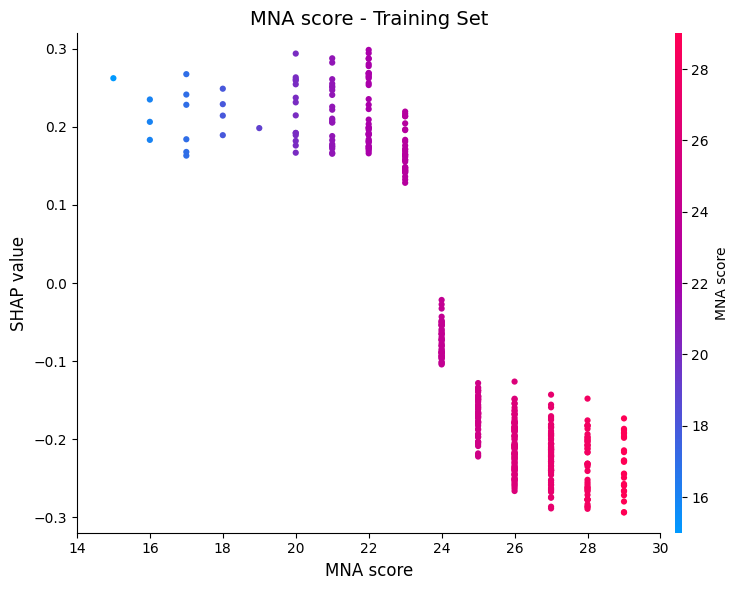

繪圖樣本數：191
MNA score 的索引位置：4
MNA score 範圍：min = 15.000, max = 28.000
SHAP 值範圍：min = -0.281, max = 0.294


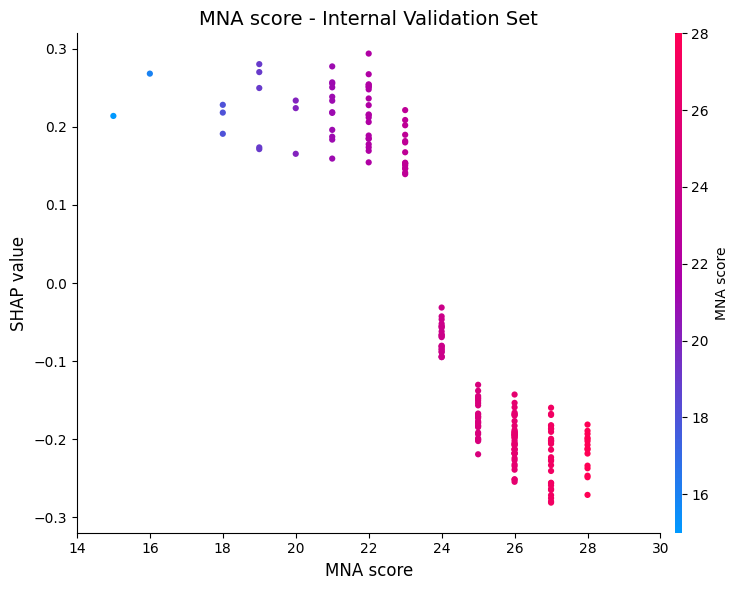

繪圖樣本數：388
MNA score 的索引位置：4
MNA score 範圍：min = 15.000, max = 29.000
SHAP 值範圍：min = -0.293, max = 0.307


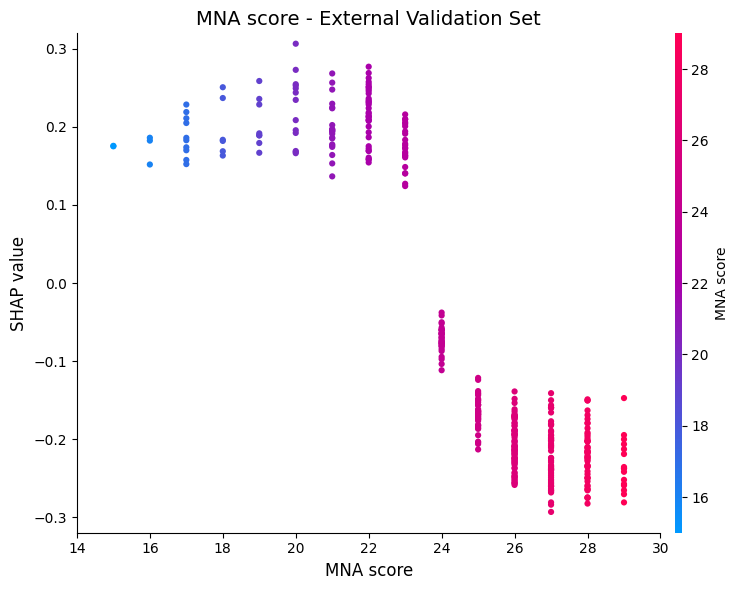

In [40]:
# MNA score
mna_train_df = plot_rf_shap_dependence(
    shap_values_train, custom_feature_names, "MNA score",
    "MNA score - Training Set", "MNA score",
    feature_type="continuous", colorbar_label="MNA score",
    xlim=(14, 30), ylim=(-0.32, 0.32),
    xticks=range(14, 31, 2), yticks=np.arange(-0.30, 0.31, 0.10),
)

mna_internal_df = plot_rf_shap_dependence(
    shap_values_intest, custom_feature_names, "MNA score",
    "MNA score - Internal Validation Set", "MNA score",
    feature_type="continuous", colorbar_label="MNA score",
    xlim=(14, 30), ylim=(-0.32, 0.32),
    xticks=range(14, 31, 2), yticks=np.arange(-0.30, 0.31, 0.10),
)

mna_external_df = plot_rf_shap_dependence(
    shap_values_extest, custom_feature_names, "MNA score",
    "MNA score - External Validation Set", "MNA score",
    feature_type="continuous", colorbar_label="MNA score",
    xlim=(14, 30), ylim=(-0.32, 0.32),
    xticks=range(14, 31, 2), yticks=np.arange(-0.30, 0.31, 0.10),
)

繪圖樣本數：445
NLR 的索引位置：1
NLR 範圍：min = 0.596, max = 18.200
SHAP 值範圍：min = -0.037, max = 0.025


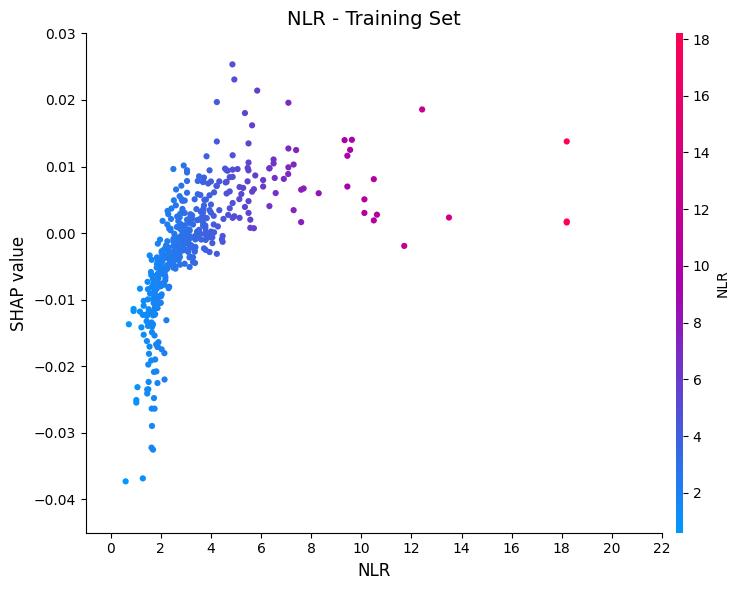

繪圖樣本數：191
NLR 的索引位置：1
NLR 範圍：min = 1.051, max = 21.500
SHAP 值範圍：min = -0.033, max = 0.024


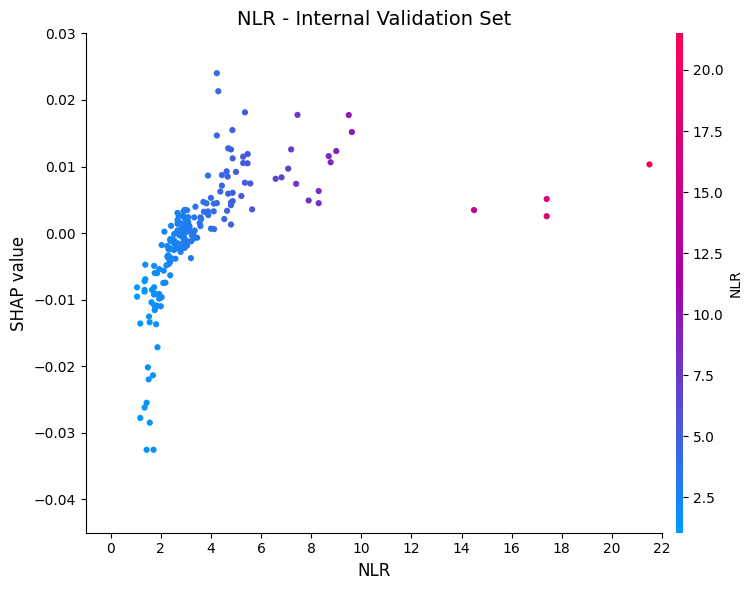

繪圖樣本數：388
NLR 的索引位置：1
NLR 範圍：min = 0.596, max = 18.200
SHAP 值範圍：min = -0.040, max = 0.024


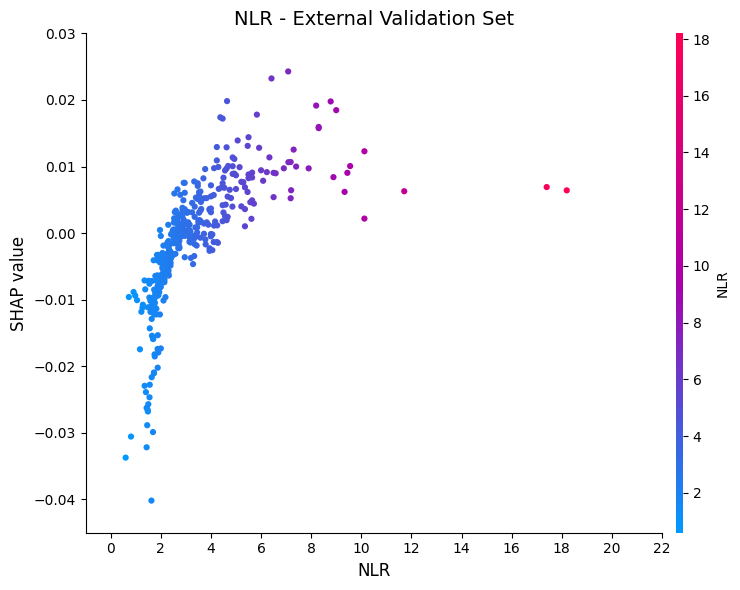

In [41]:
#  NLR
nlr_train_df = plot_rf_shap_dependence(
    shap_values_train, custom_feature_names, "NLR",
    "NLR - Training Set", "NLR",
    feature_type="continuous", colorbar_label="NLR",
    xlim=(-1, 22), ylim=(-0.045, 0.03),
    xticks=range(0, 23, 2), yticks=np.arange(-0.04, 0.031, 0.01),
)

nlr_internal_df = plot_rf_shap_dependence(
    shap_values_intest, custom_feature_names, "NLR",
    "NLR - Internal Validation Set", "NLR",
    feature_type="continuous", colorbar_label="NLR",
    xlim=(-1, 22), ylim=(-0.045, 0.03),
    xticks=range(0, 23, 2), yticks=np.arange(-0.04, 0.031, 0.01),
)

nlr_external_df = plot_rf_shap_dependence(
    shap_values_extest, custom_feature_names, "NLR",
    "NLR - External Validation Set", "NLR",
    feature_type="continuous", colorbar_label="NLR",
    xlim=(-1, 22), ylim=(-0.045, 0.03),
    xticks=range(0, 23, 2), yticks=np.arange(-0.04, 0.031, 0.01),
)

In [17]:
# chemotherapy標籤
chemotherapy_ticks = [0, 1]
chemotherapy_labels = ["No", "Yes"]

繪圖樣本數：445
Chemotherapy 的索引位置：17
Chemotherapy 範圍：min = 0.000, max = 1.000
SHAP 值範圍：min = -0.197, max = 0.058


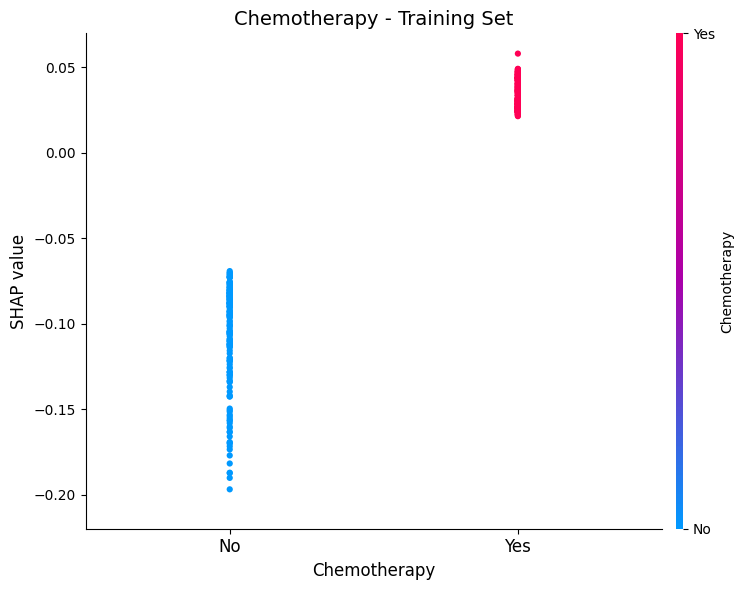

In [18]:
#  chemotherapy- Training

chemotherapy_train_df = plot_rf_shap_dependence(
    shap_values=shap_values_train,
    feature_names=custom_feature_names,
    feature_name="Chemotherapy",
    title="Chemotherapy - Training Set",
    x_label="Chemotherapy",
    colorbar_label="Chemotherapy",
    feature_type="categorical",
    xlim=(-0.5, 1.5),
    ylim=(-0.22, 0.07),
    yticks=np.arange(-0.20, 0.071, 0.05),
    category_ticks=chemotherapy_ticks,
    category_labels=chemotherapy_labels,
)

繪圖樣本數：191
Chemotherapy 的索引位置：17
Chemotherapy 範圍：min = 0.000, max = 1.000
SHAP 值範圍：min = -0.185, max = 0.053


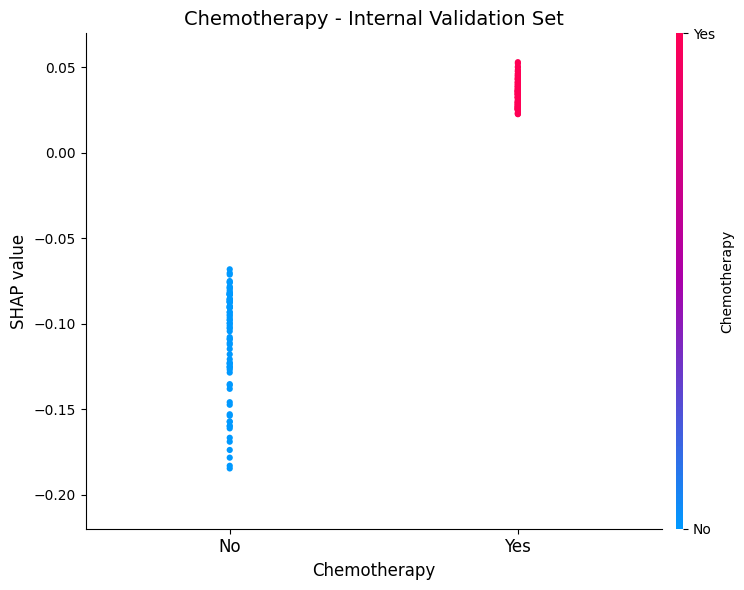

In [19]:
# chemotherapy - Internal validation

chemotherapy_internal_df = plot_rf_shap_dependence(
    shap_values=shap_values_intest,
    feature_names=custom_feature_names,
    feature_name="Chemotherapy",
    title="Chemotherapy - Internal Validation Set",
    x_label="Chemotherapy",
    colorbar_label="Chemotherapy",
    feature_type="categorical",
    xlim=(-0.5, 1.5),
    ylim=(-0.22, 0.07),
    yticks=np.arange(-0.20, 0.071, 0.05),
    category_ticks=chemotherapy_ticks,
    category_labels=chemotherapy_labels,
)

繪圖樣本數：388
Chemotherapy 的索引位置：17
Chemotherapy 範圍：min = 0.000, max = 1.000
SHAP 值範圍：min = -0.182, max = 0.054


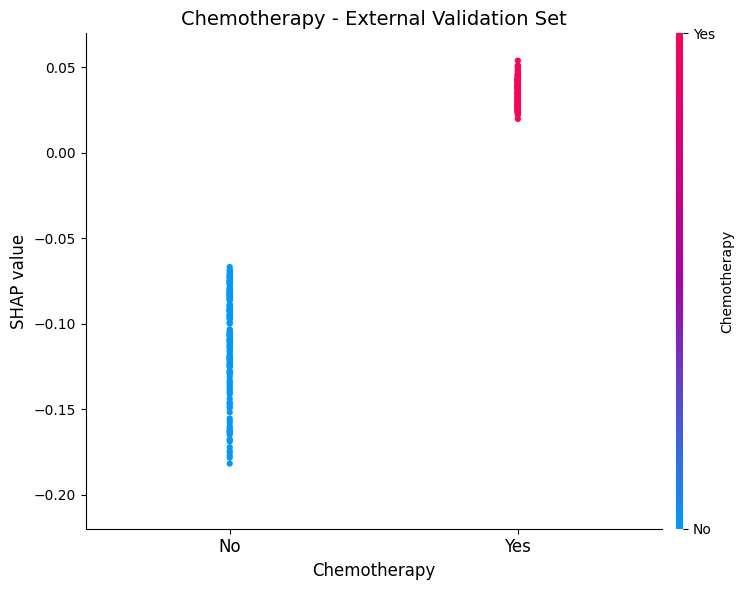

In [20]:
# chemotherapy - External validation

chemotherapy_external_df = plot_rf_shap_dependence(
    shap_values=shap_values_extest,
    feature_names=custom_feature_names,
    feature_name="Chemotherapy",
    title="Chemotherapy - External Validation Set",
    x_label="Chemotherapy",
    colorbar_label="Chemotherapy",
    feature_type="categorical",
    xlim=(-0.5, 1.5),
    ylim=(-0.22, 0.07),
    yticks=np.arange(-0.20, 0.071, 0.05),
    category_ticks=chemotherapy_ticks,
    category_labels=chemotherapy_labels,
)

# force plot

In [42]:
import os
import numpy as np
import pandas as pd
import shap
# 初始化 SHAP 的 JavaScript
shap.initjs()
# 建立樣本的 SHAP force plot 並輸出為 HTML
def create_rf_forceplots(
    model, X, subject_ids, feature_names, dataset_title, out_html,
    continuous_display_cols=None, class_index=1
):
    # 若未指定連續型特徵，使用預設的連續型特徵名單
    if continuous_display_cols is None:
        continuous_display_cols = [
            "NLR", "Pre-SMI", "CE Dmean", "CPA Dmean", "EIM Dmean",
            "GL Dmean", "IPCM Dmean", "MPCM Dmean", "SPCM Dmean", "SGL Dmean"
        ]
    # 將輸入資料轉換為 DataFrame，並將研究對象 ID 轉換為陣列
    X_df = pd.DataFrame(np.asarray(X), columns=feature_names)
    subject_ids = np.asarray(subject_ids)
    # 檢查特徵資料與研究對象 ID 的筆數是否一致
    if len(X_df) != len(subject_ids):
        raise ValueError(f"X 有 {len(X_df)} 筆，但 subject_ids 有 {len(subject_ids)} 筆")
    # 建立 HTML 輸出資料夾
    os.makedirs(os.path.dirname(out_html) or ".", exist_ok=True)
    # 計算指定類別的預測機率，並建立 TreeExplainer 計算 SHAP 值
    model_probs = model.predict_proba(X_df.to_numpy())[:, class_index]
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_df.to_numpy())
    # 取得指定類別的 SHAP 基準值
    expected_value = np.asarray(explainer.expected_value)
    base_value = expected_value[class_index] if expected_value.ndim > 0 else float(expected_value)
    # 建立 HTML 文件的基本架構
    html_parts = [
        "<!DOCTYPE html><html><head><meta charset='utf-8'>",
        "<script src='https://cdnjs.cloudflare.com/ajax/libs/require.js/2.3.6/require.min.js'></script>",
        shap.getjs(),
        """
        <style>
          body { font-family: Arial, sans-serif; margin: 20px; background-color: #f9f9f9; }
          h2 { text-align: center; color: #333; }
          .card { margin: 24px auto; padding: 14px 18px; border: 1px solid #ddd;
                  border-radius: 10px; background: white; max-width: 1800px;
                  box-shadow: 0 2px 6px rgba(0,0,0,0.06); }
          .title { font-size: 15px; font-weight: 600; color: #222; margin-bottom: 8px; }
          .sep { height: 1px; background: #eee; margin: 12px 0; }
          .force-container { width: 100%; overflow-x: visible; display: flex; justify-content: center; }
          .force-inner { width: 95%; max-width: 1800px; transform: scale(1); transform-origin: center top; }
          @media (max-width: 1500px) { .force-inner { transform: scale(0.9); } }
          @media (max-width: 1200px) { .force-inner { transform: scale(0.8); } }
          @media (max-width: 900px) { .force-inner { transform: scale(0.7); } }
        </style>
        """,
        "</head><body>",
        f"<h2>SHAP Force Plots — Random Forest ({dataset_title}, {len(X_df)} Samples)</h2>",
    ]
    # 逐一建立每位研究對象的 SHAP force plot
    for i in range(len(X_df)):
        # 取得完整 SHAP 值
        values = np.asarray(shap_values.values)
        # 若 SHAP 結果包含不同類別，取得指定類別的 SHAP 值
        if values.ndim == 3:
            shap_vals = values[i, :, class_index]
        elif values.ndim == 2:
            shap_vals = values[i, :]
        else:
            raise ValueError(f"Unexpected SHAP value shape: {values.shape}")

        row_values = X_df.iloc[i].to_numpy()
        feature_labels = []
        # 依照特徵類型設定數值的顯示方式
        for name, value in zip(feature_names, row_values):
            if name == "Sex":
                label_value = "Male" if value == 2 else "Female"
            elif name == "Chemotherapy":
                label_value = "Yes" if value == 1 else "No"
            elif name in continuous_display_cols:
                label_value = f"{value:.1f}"
            else:
                label_value = str(int(value))

            feature_labels.append(f"{name} = {label_value}")
        # 建立 SHAP force plot
        vis = shap.plots.force(
            base_value,
            shap_vals.reshape(1, -1),
            features=feature_labels,
            link="identity",
            matplotlib=False,
            show=False,
        )
        # 取得研究對象 ID 及模型預測機率
        subject_id = subject_ids[i]
        subject_text = int(subject_id) if float(subject_id).is_integer() else subject_id
        probability = model_probs[i]
        # 將研究對象資訊及 force plot 加入 HTML
        html_parts.extend([
            '<div class="card">',
            f'<div class="title">Subject ID = {subject_text} | '
            f'Predicted probability = {probability:.3f}</div>',
            '<div class="sep"></div>',
            f'<div class="force-container"><div class="force-inner">{vis.html()}</div></div>',
            "</div>",
        ])
        # 顯示目前完成的研究對象及其預測機率
        print(
            f"✅ Subject ID = {subject_text} | "
            f"Predicted probability = {probability:.3f}"
        )

    html_parts.append("</body></html>")

    with open(out_html, "w", encoding="utf-8") as file:
        file.write("".join(html_parts))

    print(f"\n🎯 最終輸出 SHAP force plot 數量：{len(X_df)}")
    print(f"📄 HTML 檔案已儲存：{os.path.abspath(out_html)}")

    return {
        "html_path": os.path.abspath(out_html),
        "shap_values": shap_values,
        "model_probabilities": model_probs,
    }

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [43]:
rf_force_train = create_rf_forceplots(
    model=rf_clf_final,
    X=rf_bundle["X_train_ordered"],
    subject_ids=rf_bundle["train_ids"],
    feature_names=custom_feature_names,
    dataset_title="Train Set",
    out_html="shap_force_plots_rf/forceplots_train_rf_modelprob_1018.html",
)

✅ Subject ID = 99991 | Predicted probability = 0.107
✅ Subject ID = 99993 | Predicted probability = 0.104
✅ Subject ID = 99994 | Predicted probability = 0.032
✅ Subject ID = 99997 | Predicted probability = 0.282
✅ Subject ID = 99998 | Predicted probability = 0.021
✅ Subject ID = 99999 | Predicted probability = 0.213
✅ Subject ID = 100002 | Predicted probability = 0.142
✅ Subject ID = 100003 | Predicted probability = 0.087
✅ Subject ID = 100005 | Predicted probability = 0.048
✅ Subject ID = 100007 | Predicted probability = 0.150
✅ Subject ID = 100010 | Predicted probability = 0.123
✅ Subject ID = 100012 | Predicted probability = 0.184
✅ Subject ID = 100013 | Predicted probability = 0.338
✅ Subject ID = 100015 | Predicted probability = 0.057
✅ Subject ID = 100016 | Predicted probability = 0.226
✅ Subject ID = 100019 | Predicted probability = 0.073
✅ Subject ID = 100021 | Predicted probability = 0.051
✅ Subject ID = 100023 | Predicted probability = 0.082
✅ Subject ID = 100024 | Predicted 

In [44]:
rf_force_internal = create_rf_forceplots(
    model=rf_clf_final,
    X=rf_bundle["X_internal_ordered"],
    subject_ids=rf_bundle["internal_ids"],
    feature_names=custom_feature_names,
    dataset_title="Internal Validation Set",
    out_html="shap_force_plots_rf/forceplots_internal_rf_modelprob_1018.html",
)

✅ Subject ID = 99992 | Predicted probability = 0.102
✅ Subject ID = 99995 | Predicted probability = 0.329
✅ Subject ID = 100001 | Predicted probability = 0.138
✅ Subject ID = 100004 | Predicted probability = 0.816
✅ Subject ID = 100008 | Predicted probability = 0.025
✅ Subject ID = 100009 | Predicted probability = 0.037
✅ Subject ID = 100017 | Predicted probability = 0.268
✅ Subject ID = 100018 | Predicted probability = 0.820
✅ Subject ID = 100026 | Predicted probability = 0.229
✅ Subject ID = 100031 | Predicted probability = 0.236
✅ Subject ID = 100033 | Predicted probability = 0.133
✅ Subject ID = 100040 | Predicted probability = 0.064
✅ Subject ID = 100042 | Predicted probability = 0.418
✅ Subject ID = 100045 | Predicted probability = 0.049
✅ Subject ID = 100051 | Predicted probability = 0.162
✅ Subject ID = 100052 | Predicted probability = 0.092
✅ Subject ID = 100053 | Predicted probability = 0.058
✅ Subject ID = 100055 | Predicted probability = 0.614
✅ Subject ID = 100059 | Predic

In [45]:
rf_force_external = create_rf_forceplots(
    model=rf_clf_final,
    X=rf_bundle["X_external_ordered"],
    subject_ids=rf_bundle["external_ids"],
    feature_names=custom_feature_names,
    dataset_title="External Validation Set",
    out_html="shap_force_plots_rf/forceplots_external_rf_modelprob_1018.html",
)

✅ Subject ID = 1 | Predicted probability = 0.272
✅ Subject ID = 3 | Predicted probability = 0.045
✅ Subject ID = 4 | Predicted probability = 0.099
✅ Subject ID = 5 | Predicted probability = 0.215
✅ Subject ID = 6 | Predicted probability = 0.103
✅ Subject ID = 7 | Predicted probability = 0.127
✅ Subject ID = 8 | Predicted probability = 0.115
✅ Subject ID = 9 | Predicted probability = 0.191
✅ Subject ID = 10 | Predicted probability = 0.161
✅ Subject ID = 11 | Predicted probability = 0.530
✅ Subject ID = 12 | Predicted probability = 0.235
✅ Subject ID = 13 | Predicted probability = 0.112
✅ Subject ID = 14 | Predicted probability = 0.763
✅ Subject ID = 15 | Predicted probability = 0.159
✅ Subject ID = 16 | Predicted probability = 0.563
✅ Subject ID = 17 | Predicted probability = 0.095
✅ Subject ID = 18 | Predicted probability = 0.067
✅ Subject ID = 20 | Predicted probability = 0.163
✅ Subject ID = 22 | Predicted probability = 0.234
✅ Subject ID = 23 | Predicted probability = 0.221
✅ Subjec

# force plot + labal

In [46]:
import os
import numpy as np
import pandas as pd
import shap

shap.initjs()

def create_rf_forceplots_with_labels(
    model, X, y_true, subject_ids, feature_names, dataset_title, out_html,
    threshold=0.5, class_index=1
):
    continuous_display_cols = [
        "NLR", "Pre-SMI", "CE Dmean", "CPA Dmean", "EIM Dmean",
        "GL Dmean", "IPCM Dmean", "MPCM Dmean", "SPCM Dmean", "SGL Dmean"
    ]

    X_df = pd.DataFrame(np.asarray(X), columns=feature_names)
    y_true = np.asarray(y_true, dtype=int)
    subject_ids = np.asarray(subject_ids)

    if not (len(X_df) == len(y_true) == len(subject_ids)):
        raise ValueError(
            f"資料長度不一致：X={len(X_df)}, "
            f"y_true={len(y_true)}, ID={len(subject_ids)}"
        )

    os.makedirs(os.path.dirname(out_html) or ".", exist_ok=True)

    y_prob = model.predict_proba(X_df.to_numpy())[:, class_index]
    y_pred = (y_prob >= threshold).astype(int)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_df.to_numpy())
    values = np.asarray(shap_values.values)

    expected_value = np.asarray(explainer.expected_value)
    base_value = (
        expected_value[class_index]
        if expected_value.ndim > 0
        else float(expected_value)
    )

    html_parts = [
        "<!DOCTYPE html><html><head><meta charset='utf-8'>",
        "<script src='https://cdnjs.cloudflare.com/ajax/libs/require.js/2.3.6/require.min.js'></script>",
        shap.getjs(),
        """
        <style>
          body { font-family: Arial, sans-serif; margin: 20px; background-color: #f9f9f9; }
          .card { margin: 24px auto; padding: 14px 18px; border: 1px solid #ddd;
                  border-radius: 10px; background: white; max-width: 1800px;
                  box-shadow: 0 2px 6px rgba(0,0,0,0.06); }
          .title { font-size: 15px; font-weight: 600; color: #222; margin-bottom: 8px; }
          .sep { height: 1px; background: #eee; margin: 12px 0; }
          .force-container { width: 100%; overflow-x: visible; }
          .force-inner { width: 100%; max-width: 1800px; margin: auto; }
        </style>
        """,
        "</head><body>",
        f"<h2>SHAP Force Plots — Random Forest ({dataset_title}, {len(X_df)} Samples)</h2>",
    ]

    records = []

    for i in range(len(X_df)):
        if values.ndim == 3:
            shap_vals = values[i, :, class_index]
        elif values.ndim == 2:
            shap_vals = values[i, :]
        else:
            raise ValueError(f"Unexpected SHAP value shape: {values.shape}")

        true = int(y_true[i])
        pred = int(y_pred[i])
        prob = float(y_prob[i])

        if true == 1 and pred == 1:
            conf_label = "TP"
        elif true == 0 and pred == 1:
            conf_label = "FP"
        elif true == 1 and pred == 0:
            conf_label = "FN"
        else:
            conf_label = "TN"

        row_values = X_df.iloc[i].to_numpy()
        feature_labels = []

        for name, value in zip(feature_names, row_values):
            if name == "Sex":
                label_value = "Male" if value == 2 else "Female"
            elif name == "Chemotherapy":
                label_value = "Yes" if value == 1 else "No"
            elif name in continuous_display_cols:
                label_value = f"{value:.1f}"
            else:
                label_value = str(int(value))

            feature_labels.append(f"{name} = {label_value}")

        vis = shap.plots.force(
            base_value,
            shap_vals.reshape(1, -1),
            features=feature_labels,
            link="identity",
            matplotlib=False,
            show=False,
        )

        subject_id = subject_ids[i]
        try:
            subject_text = int(subject_id)
        except (TypeError, ValueError):
            subject_text = str(subject_id)

        title_text = (
            f"Subject ID = {subject_text} | Pred prob = {prob:.3f} | "
            f"True = {true} | Pred = {pred} → <b>{conf_label}</b>"
        )

        html_parts.extend([
            '<div class="card">',
            f'<div class="title">{title_text}</div>',
            '<div class="sep"></div>',
            f'<div class="force-container"><div class="force-inner">{vis.html()}</div></div>',
            "</div>",
        ])

        records.append({
            "ID": subject_id,
            "y_true": true,
            "y_prob": prob,
            "y_pred": pred,
            "classification": conf_label,
        })

        print(
            f"✅ Subject ID = {subject_text} | Pred prob = {prob:.3f} | "
            f"True = {true} | Pred = {pred} → {conf_label}"
        )

    html_parts.append("</body></html>")

    with open(out_html, "w", encoding="utf-8") as file:
        file.write("".join(html_parts))

    print(f"\n🎯 最終輸出 SHAP force plot 數量：{len(X_df)}")
    print(f"📄 HTML 檔案已儲存：{os.path.abspath(out_html)}")

    return {
        "html_path": os.path.abspath(out_html),
        "shap_values": shap_values,
        "results_df": pd.DataFrame(records),
    }

In [47]:
rf_force_train_label = create_rf_forceplots_with_labels(
    model=rf_clf_final,
    X=rf_bundle["X_train_ordered"],
    y_true=rf_bundle["y_train"],
    subject_ids=rf_bundle["train_ids"],
    feature_names=custom_feature_names,
    dataset_title="Train Set",
    out_html="shap_force_plots_rf/forceplots_train_rf_modelprob_label_1018.html",
    threshold=0.5,
)

✅ Subject ID = 99991 | Pred prob = 0.107 | True = 0 | Pred = 0 → TN
✅ Subject ID = 99993 | Pred prob = 0.104 | True = 0 | Pred = 0 → TN
✅ Subject ID = 99994 | Pred prob = 0.032 | True = 0 | Pred = 0 → TN
✅ Subject ID = 99997 | Pred prob = 0.282 | True = 0 | Pred = 0 → TN
✅ Subject ID = 99998 | Pred prob = 0.021 | True = 0 | Pred = 0 → TN
✅ Subject ID = 99999 | Pred prob = 0.213 | True = 0 | Pred = 0 → TN
✅ Subject ID = 100002 | Pred prob = 0.142 | True = 0 | Pred = 0 → TN
✅ Subject ID = 100003 | Pred prob = 0.087 | True = 0 | Pred = 0 → TN
✅ Subject ID = 100005 | Pred prob = 0.048 | True = 0 | Pred = 0 → TN
✅ Subject ID = 100007 | Pred prob = 0.150 | True = 0 | Pred = 0 → TN
✅ Subject ID = 100010 | Pred prob = 0.123 | True = 0 | Pred = 0 → TN
✅ Subject ID = 100012 | Pred prob = 0.184 | True = 0 | Pred = 0 → TN
✅ Subject ID = 100013 | Pred prob = 0.338 | True = 0 | Pred = 0 → TN
✅ Subject ID = 100015 | Pred prob = 0.057 | True = 0 | Pred = 0 → TN
✅ Subject ID = 100016 | Pred prob = 0.22

In [48]:
rf_force_internal_label = create_rf_forceplots_with_labels(
    model=rf_clf_final,
    X=rf_bundle["X_internal_ordered"],
    y_true=rf_bundle["y_internal"],
    subject_ids=rf_bundle["internal_ids"],
    feature_names=custom_feature_names,
    dataset_title="Internal Validation Set",
    out_html="shap_force_plots_rf/forceplots_internal_rf_modelprob_label_1018.html",
    threshold=0.5,
)

✅ Subject ID = 99992 | Pred prob = 0.102 | True = 0 | Pred = 0 → TN
✅ Subject ID = 99995 | Pred prob = 0.329 | True = 0 | Pred = 0 → TN
✅ Subject ID = 100001 | Pred prob = 0.138 | True = 0 | Pred = 0 → TN
✅ Subject ID = 100004 | Pred prob = 0.816 | True = 1 | Pred = 1 → TP
✅ Subject ID = 100008 | Pred prob = 0.025 | True = 0 | Pred = 0 → TN
✅ Subject ID = 100009 | Pred prob = 0.037 | True = 0 | Pred = 0 → TN
✅ Subject ID = 100017 | Pred prob = 0.268 | True = 0 | Pred = 0 → TN
✅ Subject ID = 100018 | Pred prob = 0.820 | True = 0 | Pred = 1 → FP
✅ Subject ID = 100026 | Pred prob = 0.229 | True = 0 | Pred = 0 → TN
✅ Subject ID = 100031 | Pred prob = 0.236 | True = 0 | Pred = 0 → TN
✅ Subject ID = 100033 | Pred prob = 0.133 | True = 0 | Pred = 0 → TN
✅ Subject ID = 100040 | Pred prob = 0.064 | True = 0 | Pred = 0 → TN
✅ Subject ID = 100042 | Pred prob = 0.418 | True = 1 | Pred = 0 → FN
✅ Subject ID = 100045 | Pred prob = 0.049 | True = 0 | Pred = 0 → TN
✅ Subject ID = 100051 | Pred prob = 

In [49]:
rf_force_external_label = create_rf_forceplots_with_labels(
    model=rf_clf_final,
    X=rf_bundle["X_external_ordered"],
    y_true=rf_bundle["y_external"],
    subject_ids=rf_bundle["external_ids"],
    feature_names=custom_feature_names,
    dataset_title="External Validation Set",
    out_html="shap_force_plots_rf/forceplots_external_rf_modelprob_label_1018.html",
    threshold=0.5,
)

✅ Subject ID = 1 | Pred prob = 0.272 | True = 0 | Pred = 0 → TN
✅ Subject ID = 3 | Pred prob = 0.045 | True = 0 | Pred = 0 → TN
✅ Subject ID = 4 | Pred prob = 0.099 | True = 0 | Pred = 0 → TN
✅ Subject ID = 5 | Pred prob = 0.215 | True = 0 | Pred = 0 → TN
✅ Subject ID = 6 | Pred prob = 0.103 | True = 0 | Pred = 0 → TN
✅ Subject ID = 7 | Pred prob = 0.127 | True = 0 | Pred = 0 → TN
✅ Subject ID = 8 | Pred prob = 0.115 | True = 0 | Pred = 0 → TN
✅ Subject ID = 9 | Pred prob = 0.191 | True = 0 | Pred = 0 → TN
✅ Subject ID = 10 | Pred prob = 0.161 | True = 0 | Pred = 0 → TN
✅ Subject ID = 11 | Pred prob = 0.530 | True = 0 | Pred = 1 → FP
✅ Subject ID = 12 | Pred prob = 0.235 | True = 0 | Pred = 0 → TN
✅ Subject ID = 13 | Pred prob = 0.112 | True = 0 | Pred = 0 → TN
✅ Subject ID = 14 | Pred prob = 0.763 | True = 1 | Pred = 1 → TP
✅ Subject ID = 15 | Pred prob = 0.159 | True = 0 | Pred = 0 → TN
✅ Subject ID = 16 | Pred prob = 0.563 | True = 0 | Pred = 1 → FP
✅ Subject ID = 17 | Pred prob = 0